In [1]:
import sktime
print(sktime.__version__)
from sktime.classification.interval_based import TimeSeriesForestClassifier

0.33.0


# Image

In [2]:
width_MBR = 200
height_MBR = 200

# SEP

In [3]:
import cv2
import numpy as np
import requests
from PIL import Image
import csv
from datetime import datetime
import io

# Function to convert date format
def convert_date_format(date):
    date_obj = datetime.strptime(date, "%Y-%m-%d %H:%M:%S")
    return date_obj.strftime("%Y-%m-%dT%H:%M:%SZ")
    # Helioviewer requires UTC ISO timestamps

# Define a function to process and store cropped images as NumPy arrays
cropped_images_AR_SEP = {}
index_counter = 0

def store_cropped_image(date, coord1, coord2): # fetches image for SEP event time
    global index_counter
    base_url = "https://api.helioviewer.org/v2/"
    endpoint = "getJP2Image"    # Full-disk image
    source_id = "3"     # specific data source

    formatted_date = convert_date_format(date)

    url = f"{base_url}{endpoint}/?date={formatted_date}&sourceId={source_id}"
    response = requests.get(url)
        #converts to API, builds URL request and calls API to download image
    if response.status_code == 200:
        try:
            img = Image.open(io.BytesIO(response.content)).convert('L')  # Convert to grayscale

            metadata = {
                'event_coord1': coord1 / 2.63,
                'event_coord2': coord2 / 2.63,
            }   # heliographic arcseconds into pixel coordinates

            width_of_rectangle_arcsec = width_MBR
            height_of_rectangle_arcsec = height_MBR

            center_x = img.width // 2
            center_y = img.height // 2

            width_of_rectangle_pixels = width_of_rectangle_arcsec
            height_of_rectangle_pixels = height_of_rectangle_arcsec

            x1 = center_x + int(metadata['event_coord1']) - (width_of_rectangle_pixels // 2)
            y1 = center_y - int(metadata['event_coord2']) - (height_of_rectangle_pixels // 2)
            x2 = x1 + width_of_rectangle_pixels
            y2 = y1 + height_of_rectangle_pixels

            cropped_image = np.array(img.crop((x1, y1, x2, y2)))  # Convert to NumPy array

            # Binarize the image
            _, thresh = cv2.threshold(cropped_image, 128, 255, cv2.THRESH_BINARY)

            # Find contours on the binarized image
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            x, y, w, h = cv2.boundingRect(contours[0]) if contours else (0, 0, 0, 0)
            mbr = cropped_image[y:y+h, x:x+w]  # Get the MBR region

            cropped_images_AR_SEP[index_counter] = mbr
            index_counter += 1
            print(f"MBR for {date} processed and stored as NumPy array with index {index_counter - 1}.")
        except Exception as e:
            print(f"Error processing image for {date}: {e}")
    else:
        print(f"Failed to fetch image for {date} with status code:", response.status_code)

# Open CSV file and process data
with open('SEP_date_100MeV_Dates_Flares_AR.csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        date = row['SEP100']
        coord1 = float(row['Coord1'])
        coord2 = float(row['Coord2'])
        store_cropped_image(date, coord1, coord2)

# Further code to continue the logic as required.
# ...


MBR for 1997-11-04 05:50:00 processed and stored as NumPy array with index 0.
MBR for 1998-05-06 07:55:00 processed and stored as NumPy array with index 1.
MBR for 2000-06-10 16:40:00 processed and stored as NumPy array with index 2.
MBR for 2000-07-14 10:00:00 processed and stored as NumPy array with index 3.
MBR for 2000-07-22 11:15:00 processed and stored as NumPy array with index 4.
MBR for 2000-09-12 11:30:00 processed and stored as NumPy array with index 5.
MBR for 2000-11-24 14:50:00 processed and stored as NumPy array with index 6.
MBR for 2000-11-25 00:55:00 processed and stored as NumPy array with index 7.
MBR for 2001-01-28 15:40:00 processed and stored as NumPy array with index 8.
MBR for 2001-04-09 15:20:00 processed and stored as NumPy array with index 9.
MBR for 2001-04-15 13:15:00 processed and stored as NumPy array with index 10.
MBR for 2001-05-20 06:00:00 processed and stored as NumPy array with index 11.
MBR for 2001-06-15 16:15:00 processed and stored as NumPy arra

In [4]:
cropped_images_AR_SEP[0]

array([[156, 159, 157, ..., 167, 184, 176],
       [157, 158, 158, ..., 171, 182, 178],
       [157, 158, 158, ..., 175, 177, 180],
       ...,
       [206, 208, 217, ..., 162, 154, 145],
       [203, 207, 207, ..., 170, 138, 158],
       [201, 202, 202, ..., 164, 146, 153]], dtype=uint8)

In [5]:
import requests
from PIL import Image
import csv
from datetime import datetime
import io
import numpy as np
import cv2

# Function to convert date format
def convert_date_format(date):
    date_obj = datetime.strptime(date, "%Y-%m-%d %H:%M:%S")
    return date_obj.strftime("%Y-%m-%dT%H:%M:%SZ")

# Define a function to process and store cropped images as NumPy arrays
cropped_images_AR_SEP = {}
index_counter = 0

def store_cropped_image(date, coord1, coord2):
    global index_counter
    base_url = "https://api.helioviewer.org/v2/"
    endpoint = "getJP2Image"
    source_id = "3"

    formatted_date = convert_date_format(date)

    url = f"{base_url}{endpoint}/?date={formatted_date}&sourceId={source_id}"
    response = requests.get(url)

    if response.status_code == 200:
        try:
            img = Image.open(io.BytesIO(response.content)).convert('L')  # Convert to grayscale

            metadata = {
                'event_coord1': coord1 / 2.63,
                'event_coord2': coord2 / 2.63,
            }

            width_of_rectangle_arcsec = width_MBR
            height_of_rectangle_arcsec = height_MBR

            center_x = img.width // 2
            center_y = img.height // 2

            width_of_rectangle_pixels = width_of_rectangle_arcsec
            height_of_rectangle_pixels = height_of_rectangle_arcsec

            x1 = center_x + int(metadata['event_coord1']) - (width_of_rectangle_pixels // 2)
            y1 = center_y - int(metadata['event_coord2']) - (height_of_rectangle_pixels // 2)
            x2 = x1 + width_of_rectangle_pixels
            y2 = y1 + height_of_rectangle_pixels

            cropped_image = np.array(img.crop((x1, y1, x2, y2)))  # Convert to NumPy array

            # Threshold to obtain the brightest parts
            _, thresh = cv2.threshold(cropped_image, 200, 255, cv2.THRESH_BINARY)

            # Find contours
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            # Draw contours on the cropped image
            cv2.drawContours(cropped_image, contours, -1, (0, 255, 0), 2)

            # Store the processed image
            cropped_images_AR_SEP[index_counter] = cropped_image
            index_counter += 1
            print(f"Cropped image for {date} processed and stored as NumPy array with index {index_counter - 1}.")
        except Exception as e:
            print(f"Error processing image for {date}: {e}")
    else:
        print(f"Failed to fetch image for {date} with status code:", response.status_code)

# Open CSV file and process data
with open('SEP_date_100MeV_Dates_Flares_AR.csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        date = row['SEP100']
        coord1 = float(row['Coord1'])
        coord2 = float(row['Coord2'])
        store_cropped_image(date, coord1, coord2)


Cropped image for 1997-11-04 05:50:00 processed and stored as NumPy array with index 0.
Cropped image for 1998-05-06 07:55:00 processed and stored as NumPy array with index 1.
Cropped image for 2000-06-10 16:40:00 processed and stored as NumPy array with index 2.
Cropped image for 2000-07-14 10:00:00 processed and stored as NumPy array with index 3.
Cropped image for 2000-07-22 11:15:00 processed and stored as NumPy array with index 4.
Cropped image for 2000-09-12 11:30:00 processed and stored as NumPy array with index 5.
Cropped image for 2000-11-24 14:50:00 processed and stored as NumPy array with index 6.
Cropped image for 2000-11-25 00:55:00 processed and stored as NumPy array with index 7.
Cropped image for 2001-01-28 15:40:00 processed and stored as NumPy array with index 8.
Cropped image for 2001-04-09 15:20:00 processed and stored as NumPy array with index 9.
Cropped image for 2001-04-15 13:15:00 processed and stored as NumPy array with index 10.
Cropped image for 2001-05-20 06

In [ ]:
cropped_images_AR_SEP[0]

array([[156, 159, 157, ..., 167, 184, 176],
       [157, 158, 158, ..., 171, 182, 178],
       [157, 158, 158, ..., 175, 177, 180],
       ...,
       [  0,   0,   0, ..., 162, 154, 145],
       [  0,   0,   0, ..., 170, 138, 158],
       [  0,   0,   0, ..., 164, 146, 153]], dtype=uint8)

In [ ]:
import requests
from PIL import Image
import csv
from datetime import datetime
import io
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Function to convert date format
def convert_date_format(date):
    date_obj = datetime.strptime(date, "%Y-%m-%d %H:%M:%S")
    return date_obj.strftime("%Y-%m-%dT%H:%M:%SZ")

# Define a function to process and store cropped images as NumPy arrays
cropped_images_AR_SEP = {}
index_counter = 0

def store_cropped_image(date, coord1, coord2):
    global index_counter
    base_url = "https://api.helioviewer.org/v2/"
    endpoint = "getJP2Image"
    source_id = "3"

    formatted_date = convert_date_format(date)

    url = f"{base_url}{endpoint}/?date={formatted_date}&sourceId={source_id}"
    response = requests.get(url)

    if response.status_code == 200:
        try:
            img = Image.open(io.BytesIO(response.content)).convert('L')  # Convert to grayscale

            metadata = {
                'event_coord1': coord1 / 2.63,
                'event_coord2': coord2 / 2.63,
            }

            width_of_rectangle_arcsec = width_MBR
            height_of_rectangle_arcsec = height_MBR

            center_x = img.width // 2
            center_y = img.height // 2

            width_of_rectangle_pixels = width_of_rectangle_arcsec
            height_of_rectangle_pixels = height_of_rectangle_arcsec

            x1 = center_x + int(metadata['event_coord1']) - (width_of_rectangle_pixels // 2)
            y1 = center_y - int(metadata['event_coord2']) - (height_of_rectangle_pixels // 2)
            x2 = x1 + width_of_rectangle_pixels
            y2 = y1 + height_of_rectangle_pixels

            cropped_image = np.array(img.crop((x1, y1, x2, y2)))  # Convert to NumPy array

            # Threshold to obtain the brightest parts
            _, thresh = cv2.threshold(cropped_image, 200, 255, cv2.THRESH_BINARY)

            # Find contours
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            # Create a blank mask image
            mask = np.zeros_like(cropped_image)

            # Draw contours on the mask
            cv2.drawContours(mask, contours, -1, (255), thickness=cv2.FILLED)

            # Apply the mask to the cropped image
            result = np.where(mask != 0, cropped_image, 0)

            # Store the processed image
            cropped_images_AR_SEP[index_counter] = result
            index_counter += 1
            print(f"Cropped image for {date} processed and stored as NumPy array with index {index_counter - 1}.")
        except Exception as e:
            print(f"Error processing image for {date}: {e}")
    else:
        print(f"Failed to fetch image for {date} with status code:", response.status_code)

# Open CSV file and process data
with open('SEP_date_100MeV_Dates_Flares_AR.csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        date = row['SEP100']
        coord1 = float(row['Coord1'])
        coord2 = float(row['Coord2'])
        store_cropped_image(date, coord1, coord2)



Cropped image for 1997-11-04 05:50:00 processed and stored as NumPy array with index 0.
Cropped image for 1998-05-06 07:55:00 processed and stored as NumPy array with index 1.
Cropped image for 2000-06-10 16:40:00 processed and stored as NumPy array with index 2.
Cropped image for 2000-07-14 10:00:00 processed and stored as NumPy array with index 3.
Cropped image for 2000-07-22 11:15:00 processed and stored as NumPy array with index 4.
Cropped image for 2000-09-12 11:30:00 processed and stored as NumPy array with index 5.
Cropped image for 2000-11-24 14:50:00 processed and stored as NumPy array with index 6.
Cropped image for 2000-11-25 00:55:00 processed and stored as NumPy array with index 7.
Cropped image for 2001-01-28 15:40:00 processed and stored as NumPy array with index 8.
Cropped image for 2001-04-09 15:20:00 processed and stored as NumPy array with index 9.
Cropped image for 2001-04-15 13:15:00 processed and stored as NumPy array with index 10.
Cropped image for 2001-05-20 06

In [ ]:
cropped_images_AR_SEP[0]

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [206, 208, 217, ...,   0,   0,   0],
       [203, 207, 207, ...,   0,   0,   0],
       [201, 202, 202, ...,   0,   0,   0]], dtype=uint8)

## SEP Mask

In [ ]:
import requests
from PIL import Image
import csv
from datetime import datetime
import io
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Function to convert date format
def convert_date_format(date):
    date_obj = datetime.strptime(date, "%Y-%m-%d %H:%M:%S")
    return date_obj.strftime("%Y-%m-%dT%H:%M:%SZ")

# Define a function to process and store cropped images as NumPy arrays
cropped_images_AR_SEP = {}
index_counter = 0

def store_cropped_image(date, coord1, coord2):
    global index_counter
    base_url = "https://api.helioviewer.org/v2/"
    endpoint = "getJP2Image"
    source_id = "3"

    formatted_date = convert_date_format(date)

    url = f"{base_url}{endpoint}/?date={formatted_date}&sourceId={source_id}"
    response = requests.get(url)

    if response.status_code == 200:
        try:
            img = Image.open(io.BytesIO(response.content)).convert('L')  # Convert to grayscale

            metadata = {
                'event_coord1': coord1 / 2.63,  #for SDO
                'event_coord2': coord2 / 2.63,  #arcsec/pixel
            }

            width_of_rectangle_arcsec = width_MBR
            height_of_rectangle_arcsec = height_MBR

            center_x = img.width // 2
            center_y = img.height // 2

            width_of_rectangle_pixels = width_of_rectangle_arcsec
            height_of_rectangle_pixels = height_of_rectangle_arcsec

            x1 = center_x + int(metadata['event_coord1']) - (width_of_rectangle_pixels // 2)
            y1 = center_y - int(metadata['event_coord2']) - (height_of_rectangle_pixels // 2)
            x2 = x1 + width_of_rectangle_pixels
            y2 = y1 + height_of_rectangle_pixels

            cropped_image = np.array(img.crop((x1, y1, x2, y2)))  # Convert to NumPy array

            # Threshold to obtain the brightest parts
            _, thresh = cv2.threshold(cropped_image, 200, 255, cv2.THRESH_BINARY)



            # Find contours
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            # Keep only the largest contour
            contour_areas = [cv2.contourArea(contour) for contour in contours]
            largest_contour_index = np.argmax(contour_areas)
            largest_contour = contours[largest_contour_index]

            # Create a blank mask image
            mask = np.zeros_like(cropped_image)

            # Draw largest contour on the mask
            cv2.drawContours(mask, [largest_contour], -1, (255), thickness=cv2.FILLED)

            # Apply the mask to the cropped image
            result = np.where(mask != 0, cropped_image, 0)

            # Store the processed image
            cropped_images_AR_SEP[index_counter] = result
            index_counter += 1
            print(f"Cropped image for {date} processed and stored as NumPy array with index {index_counter - 1}.")
        except Exception as e:
            print(f"Error processing image for {date}: {e}")
    else:
        print(f"Failed to fetch image for {date} with status code:", response.status_code)

# Open CSV file and process data
with open('SEP_date_100MeV_Dates_Flares_AR.csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        date = row['SEP100']
        coord1 = float(row['Coord1'])
        coord2 = float(row['Coord2'])
        store_cropped_image(date, coord1, coord2)



Cropped image for 1997-11-04 05:50:00 processed and stored as NumPy array with index 0.
Cropped image for 1998-05-06 07:55:00 processed and stored as NumPy array with index 1.
Cropped image for 2000-06-10 16:40:00 processed and stored as NumPy array with index 2.
Cropped image for 2000-07-14 10:00:00 processed and stored as NumPy array with index 3.
Cropped image for 2000-07-22 11:15:00 processed and stored as NumPy array with index 4.
Cropped image for 2000-09-12 11:30:00 processed and stored as NumPy array with index 5.
Cropped image for 2000-11-24 14:50:00 processed and stored as NumPy array with index 6.
Cropped image for 2000-11-25 00:55:00 processed and stored as NumPy array with index 7.
Cropped image for 2001-01-28 15:40:00 processed and stored as NumPy array with index 8.
Cropped image for 2001-04-09 15:20:00 processed and stored as NumPy array with index 9.
Cropped image for 2001-04-15 13:15:00 processed and stored as NumPy array with index 10.
Cropped image for 2001-05-20 06

In [ ]:
import requests
from PIL import Image
import csv
from datetime import datetime
import io
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Function to convert date format
def convert_date_format(date):
    date_obj = datetime.strptime(date, "%Y-%m-%d %H:%M:%S")
    return date_obj.strftime("%Y-%m-%dT%H:%M:%SZ")

# Define a function to process and store cropped images as NumPy arrays
cropped_images_AR_SEP = {}
index_counter = 0

def store_cropped_image(date, coord1, coord2):
    global index_counter
    base_url = "https://api.helioviewer.org/v2/"
    endpoint = "getJP2Image"
    source_id = "3"

    formatted_date = convert_date_format(date)

    url = f"{base_url}{endpoint}/?date={formatted_date}&sourceId={source_id}"
    response = requests.get(url)

    if response.status_code == 200:
        try:
            img = Image.open(io.BytesIO(response.content)).convert('L')  # Convert to grayscale

            metadata = {
                'event_coord1': coord1 / 2.63,
                'event_coord2': coord2 / 2.63,
            }
            
            
            width_of_rectangle_arcsec = width_MBR
            height_of_rectangle_arcsec = height_MBR

            center_x = img.width // 2
            center_y = img.height // 2

            width_of_rectangle_pixels = width_of_rectangle_arcsec
            height_of_rectangle_pixels = height_of_rectangle_arcsec

            x1 = center_x + int(metadata['event_coord1']) - (width_of_rectangle_pixels // 2)
            y1 = center_y - int(metadata['event_coord2']) - (height_of_rectangle_pixels // 2)
            x2 = x1 + width_of_rectangle_pixels
            y2 = y1 + height_of_rectangle_pixels

            cropped_image = np.array(img.crop((x1, y1, x2, y2)))  # Convert to NumPy array

            # Threshold to obtain the brightest parts
            _, thresh = cv2.threshold(cropped_image, 200, 255, cv2.THRESH_BINARY)

            # Find contours
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            # Keep only the largest contour
            contour_areas = [cv2.contourArea(contour) for contour in contours]
            largest_contour_index = np.argmax(contour_areas)
            largest_contour = contours[largest_contour_index]

            # Create a blank mask image
            mask = np.zeros_like(cropped_image)

            # Draw largest contour on the mask
            cv2.drawContours(mask, [largest_contour], -1, (255), thickness=cv2.FILLED)

            # Apply the mask to the cropped image
            result = np.where(mask != 0, cropped_image, 0)

            # Store the processed image
            cropped_images_AR_SEP[index_counter] = result
            index_counter += 1
            print(f"Cropped image for {date} processed and stored as NumPy array with index {index_counter - 1}.")
        except Exception as e:
            print(f"Error processing image for {date}: {e}")
    else:
        print(f"Failed to fetch image for {date} with status code:", response.status_code)

# Open CSV file and process data
with open('SEP_date_100MeV_Dates_Flares_AR.csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        date = row['SEP100']
        coord1 = float(row['Coord1'])
        coord2 = float(row['Coord2'])
        store_cropped_image(date, coord1, coord2)

# Adjust the bright shapes to the center of each image
adjusted_images_AR_SEP = {}

for index, image in cropped_images_AR_SEP.items():
    # Calculate the center of mass (centroid) of the brightest region
    M = cv2.moments(image)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        cX, cY = 0, 0

    # Shift the image so that the centroid is at the center
    rows, cols = image.shape
    shiftX = cols // 2 - cX
    shiftY = rows // 2 - cY
    M = np.float32([[1, 0, shiftX], [0, 1, shiftY]])
    adjusted_image = cv2.warpAffine(image, M, (cols, rows))

    # Store the adjusted image
    adjusted_images_AR_SEP[index] = adjusted_image

    # # Optionally, visualize the adjusted image
    # plt.imshow(adjusted_image, cmap='gray')
    # plt.title(f"Adjusted Image {index}")
    # plt.axis('off')
    # plt.show()


Cropped image for 1997-11-04 05:50:00 processed and stored as NumPy array with index 0.
Cropped image for 1998-05-06 07:55:00 processed and stored as NumPy array with index 1.
Cropped image for 2000-06-10 16:40:00 processed and stored as NumPy array with index 2.
Cropped image for 2000-07-14 10:00:00 processed and stored as NumPy array with index 3.
Cropped image for 2000-07-22 11:15:00 processed and stored as NumPy array with index 4.
Cropped image for 2000-09-12 11:30:00 processed and stored as NumPy array with index 5.
Cropped image for 2000-11-24 14:50:00 processed and stored as NumPy array with index 6.
Cropped image for 2000-11-25 00:55:00 processed and stored as NumPy array with index 7.
Cropped image for 2001-01-28 15:40:00 processed and stored as NumPy array with index 8.
Cropped image for 2001-04-09 15:20:00 processed and stored as NumPy array with index 9.
Cropped image for 2001-04-15 13:15:00 processed and stored as NumPy array with index 10.
Cropped image for 2001-05-20 06

In [11]:
import requests
from PIL import Image
import csv
from datetime import datetime
import io
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Function to convert date format
def convert_date_format(date):
    date_obj = datetime.strptime(date, "%Y-%m-%d %H:%M:%S")
    return date_obj.strftime("%Y-%m-%dT%H:%M:%SZ")

# Define a function to process and store cropped images as NumPy arrays
cropped_images_AR_SEP = {}
index_counter = 0

USE_ADAPTIVE = False   # False to use old fixed threshold

def store_cropped_image(date, coord1, coord2):
    global index_counter
    base_url = "https://api.helioviewer.org/v2/"
    endpoint = "getJP2Image"
    source_id = "3"

    formatted_date = convert_date_format(date)

    url = f"{base_url}{endpoint}/?date={formatted_date}&sourceId={source_id}"
    response = requests.get(url)

    if response.status_code == 200:
        try:
            img = Image.open(io.BytesIO(response.content)).convert('L')  # grayscale

            metadata = {
                'event_coord1': coord1 / 2.63,
                'event_coord2': coord2 / 2.63,
            }

            width_of_rectangle_arcsec = width_MBR
            height_of_rectangle_arcsec = height_MBR

            center_x = img.width // 2
            center_y = img.height // 2

            width_of_rectangle_pixels = width_of_rectangle_arcsec
            height_of_rectangle_pixels = height_of_rectangle_arcsec

            x1 = center_x + int(metadata['event_coord1']) - (width_of_rectangle_pixels // 2)
            y1 = center_y - int(metadata['event_coord2']) - (height_of_rectangle_pixels // 2)
            x2 = x1 + width_of_rectangle_pixels
            y2 = y1 + height_of_rectangle_pixels

            cropped_image = np.array(img.crop((x1, y1, x2, y2)))  # numpy array

            # THRESHOLD STEP
            if USE_ADAPTIVE:
                thresh = cv2.adaptiveThreshold(
                    cropped_image.astype(np.uint8),
                    255,
                    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                    cv2.THRESH_BINARY,
                    35,   # blockSize (odd number) – tune this
                    5     # C value – tune this
                )
            else:
                _, thresh = cv2.threshold(cropped_image, 200, 255, cv2.THRESH_BINARY)

            # Find contours
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            # Keep only the largest contour
            if contours:
                contour_areas = [cv2.contourArea(contour) for contour in contours]
                largest_contour_index = np.argmax(contour_areas)
                largest_contour = contours[largest_contour_index]

                # Create a blank mask
                mask = np.zeros_like(cropped_image)

                # Draw largest contour on the mask
                cv2.drawContours(mask, [largest_contour], -1, (255), thickness=cv2.FILLED)

                # Apply the mask to the cropped image
                result = np.where(mask != 0, cropped_image, 0)
            else:
                result = cropped_image

            # Store the processed image
            cropped_images_AR_SEP[index_counter] = result
            index_counter += 1
            print(f"Cropped image for {date} processed and stored as NumPy array with index {index_counter - 1}.")
        except Exception as e:
            print(f"Error processing image for {date}: {e}")
    else:
        print(f"Failed to fetch image for {date} with status code:", response.status_code)

# Open CSV file and process data
with open('SEP_date_100MeV_Dates_Flares_AR.csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        date = row['SEP100']
        coord1 = float(row['Coord1'])
        coord2 = float(row['Coord2'])
        store_cropped_image(date, coord1, coord2)

    # # Optionally, visualize the adjusted image
    # plt.imshow(adjusted_image, cmap='gray')
    # plt.title(f"Adjusted Image {index}")
    # plt.axis('off')
    # plt.show()


Cropped image for 1997-11-04 05:50:00 processed and stored as NumPy array with index 0.
Cropped image for 1998-05-06 07:55:00 processed and stored as NumPy array with index 1.
Cropped image for 2000-06-10 16:40:00 processed and stored as NumPy array with index 2.
Cropped image for 2000-07-14 10:00:00 processed and stored as NumPy array with index 3.
Cropped image for 2000-07-22 11:15:00 processed and stored as NumPy array with index 4.
Cropped image for 2000-09-12 11:30:00 processed and stored as NumPy array with index 5.
Cropped image for 2000-11-24 14:50:00 processed and stored as NumPy array with index 6.
Cropped image for 2000-11-25 00:55:00 processed and stored as NumPy array with index 7.
Cropped image for 2001-01-28 15:40:00 processed and stored as NumPy array with index 8.
Cropped image for 2001-04-09 15:20:00 processed and stored as NumPy array with index 9.
Cropped image for 2001-04-15 13:15:00 processed and stored as NumPy array with index 10.
Cropped image for 2001-05-20 06

# NSEP

## NSEP Mask

In [12]:
import requests
from PIL import Image
import csv
from datetime import datetime
import io
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Function to convert date format
def convert_date_format(date):
    date_obj = datetime.strptime(date, "%Y-%m-%d %H:%M:%S")
    return date_obj.strftime("%Y-%m-%dT%H:%M:%SZ")

# Define a function to process and store cropped images as NumPy arrays
cropped_images_AR_NSEP = {}
index_counter = 0

def store_cropped_image(date, coord1, coord2):
    global index_counter
    base_url = "https://api.helioviewer.org/v2/"
    endpoint = "getJP2Image"
    source_id = "3"

    formatted_date = convert_date_format(date)

    url = f"{base_url}{endpoint}/?date={formatted_date}&sourceId={source_id}"
    response = requests.get(url)

    if response.status_code == 200:
        try:
            img = Image.open(io.BytesIO(response.content)).convert('L')  # Convert to grayscale

            metadata = {
                'event_coord1': coord1 / 2.63,
                'event_coord2': coord2 / 2.63,
            }

            width_of_rectangle_arcsec = width_MBR
            height_of_rectangle_arcsec = height_MBR

            center_x = img.width // 2
            center_y = img.height // 2

            width_of_rectangle_pixels = width_of_rectangle_arcsec
            height_of_rectangle_pixels = height_of_rectangle_arcsec

            x1 = center_x + int(metadata['event_coord1']) - (width_of_rectangle_pixels // 2)
            y1 = center_y - int(metadata['event_coord2']) - (height_of_rectangle_pixels // 2)
            x2 = x1 + width_of_rectangle_pixels
            y2 = y1 + height_of_rectangle_pixels

            cropped_image = np.array(img.crop((x1, y1, x2, y2)))  # Convert to NumPy array

            # Threshold to obtain the brightest parts
            _, thresh = cv2.threshold(cropped_image, 200, 255, cv2.THRESH_BINARY)

            # Find contours
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            # Keep only the largest contour
            contour_areas = [cv2.contourArea(contour) for contour in contours]
            largest_contour_index = np.argmax(contour_areas)
            largest_contour = contours[largest_contour_index]

            # Create a blank mask image
            mask = np.zeros_like(cropped_image)

            # Draw largest contour on the mask
            cv2.drawContours(mask, [largest_contour], -1, (255), thickness=cv2.FILLED)

            # Apply the mask to the cropped image
            result = np.where(mask != 0, cropped_image, 0)

            # Store the processed image
            cropped_images_AR_NSEP[index_counter] = result
            index_counter += 1
            print(f"Cropped image for {date} processed and stored as NumPy array with index {index_counter - 1}.")
        except Exception as e:
            print(f"Error processing image for {date}: {e}")
    else:
        print(f"Failed to fetch image for {date} with status code:", response.status_code)

# Open CSV file and process data
with open('NSEP_date_P2_Dates_AR.csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        date = row['NSEP']
        coord1 = float(row['Coord1'])
        coord2 = float(row['Coord2'])
        store_cropped_image(date, coord1, coord2)



Cropped image for 1997-11-29 22:25:00 processed and stored as NumPy array with index 0.
Cropped image for 1998-04-27 08:55:00 processed and stored as NumPy array with index 1.
Cropped image for 1998-11-23 10:55:00 processed and stored as NumPy array with index 2.
Cropped image for 1999-03-16 21:30:00 processed and stored as NumPy array with index 3.
Cropped image for 1999-04-04 05:15:00 processed and stored as NumPy array with index 4.
Cropped image for 1999-05-08 14:20:00 processed and stored as NumPy array with index 5.
Cropped image for 1999-07-24 07:45:00 processed and stored as NumPy array with index 6.
Cropped image for 1999-07-29 19:30:00 processed and stored as NumPy array with index 7.
Cropped image for 1999-08-04 05:45:00 processed and stored as NumPy array with index 8.
Cropped image for 1999-08-21 16:30:00 processed and stored as NumPy array with index 9.
Cropped image for 1999-08-25 01:30:00 processed and stored as NumPy array with index 10.
Cropped image for 1999-08-27 12

In [14]:
import requests
from PIL import Image
import csv
from datetime import datetime
import io
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Function to convert date format
def convert_date_format(date):
    date_obj = datetime.strptime(date, "%Y-%m-%d %H:%M:%S")
    return date_obj.strftime("%Y-%m-%dT%H:%M:%SZ")

# Define a function to process and store cropped images as NumPy arrays
cropped_images_AR_NSEP = {}
index_counter = 0

def store_cropped_image(date, coord1, coord2):
    global index_counter
    base_url = "https://api.helioviewer.org/v2/"
    endpoint = "getJP2Image"
    source_id = "3"

    formatted_date = convert_date_format(date)

    url = f"{base_url}{endpoint}/?date={formatted_date}&sourceId={source_id}"
    response = requests.get(url)

    if response.status_code == 200:
        try:
            img = Image.open(io.BytesIO(response.content)).convert('L')  # Convert to grayscale

            metadata = {
                'event_coord1': coord1 / 2.63,
                'event_coord2': coord2 / 2.63,
            }

            width_of_rectangle_arcsec = width_MBR
            height_of_rectangle_arcsec = height_MBR

            center_x = img.width // 2
            center_y = img.height // 2

            width_of_rectangle_pixels = width_of_rectangle_arcsec
            height_of_rectangle_pixels = height_of_rectangle_arcsec

            x1 = center_x + int(metadata['event_coord1']) - (width_of_rectangle_pixels // 2)
            y1 = center_y - int(metadata['event_coord2']) - (height_of_rectangle_pixels // 2)
            x2 = x1 + width_of_rectangle_pixels
            y2 = y1 + height_of_rectangle_pixels

            cropped_image = np.array(img.crop((x1, y1, x2, y2)))  # Convert to NumPy array

            # Threshold to obtain the brightest parts
            _, thresh = cv2.threshold(cropped_image, 200, 255, cv2.THRESH_BINARY)

            # Find contours
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            # Keep only the largest contour
            contour_areas = [cv2.contourArea(contour) for contour in contours]
            largest_contour_index = np.argmax(contour_areas)
            largest_contour = contours[largest_contour_index]

            # Create a blank mask image
            mask = np.zeros_like(cropped_image)

            # Draw largest contour on the mask
            cv2.drawContours(mask, [largest_contour], -1, (255), thickness=cv2.FILLED)

            # Apply the mask to the cropped image
            result = np.where(mask != 0, cropped_image, 0)

            # Store the processed image
            cropped_images_AR_NSEP[index_counter] = result
            index_counter += 1
            print(f"Cropped image for {date} processed and stored as NumPy array with index {index_counter - 1}.")
        except Exception as e:
            print(f"Error processing image for {date}: {e}")
    else:
        print(f"Failed to fetch image for {date} with status code:", response.status_code)

# Open CSV file and process data
with open('NSEP_date_P2_Dates_AR.csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        date = row['NSEP']
        coord1 = float(row['Coord1'])
        coord2 = float(row['Coord2'])
        store_cropped_image(date, coord1, coord2)

# Adjust the bright shapes to the center of each image
adjusted_images_AR_NSEP = {}

for index, image in cropped_images_AR_NSEP.items():
    # Calculate the center of mass (centroid) of the brightest region
    M = cv2.moments(image)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        cX, cY = 0, 0

    # Shift the image so that the centroid is at the center
    rows, cols = image.shape
    shiftX = cols // 2 - cX
    shiftY = rows // 2 - cY
    M = np.float32([[1, 0, shiftX], [0, 1, shiftY]])
    adjusted_image = cv2.warpAffine(image, M, (cols, rows))

    # Store the adjusted image
    adjusted_images_AR_NSEP[index] = adjusted_image

    # # Optionally, visualize the adjusted image
    # plt.imshow(adjusted_image, cmap='gray')
    # plt.title(f"Adjusted Image {index}")
    # plt.axis('off')
    # plt.show()


Cropped image for 1997-11-29 22:25:00 processed and stored as NumPy array with index 0.
Cropped image for 1998-04-27 08:55:00 processed and stored as NumPy array with index 1.
Cropped image for 1998-11-23 10:55:00 processed and stored as NumPy array with index 2.
Cropped image for 1999-03-16 21:30:00 processed and stored as NumPy array with index 3.
Cropped image for 1999-04-04 05:15:00 processed and stored as NumPy array with index 4.
Cropped image for 1999-05-08 14:20:00 processed and stored as NumPy array with index 5.
Cropped image for 1999-07-24 07:45:00 processed and stored as NumPy array with index 6.
Cropped image for 1999-07-29 19:30:00 processed and stored as NumPy array with index 7.
Cropped image for 1999-08-04 05:45:00 processed and stored as NumPy array with index 8.
Cropped image for 1999-08-21 16:30:00 processed and stored as NumPy array with index 9.
Cropped image for 1999-08-25 01:30:00 processed and stored as NumPy array with index 10.
Cropped image for 1999-08-27 12

In [15]:
import requests
from PIL import Image
import csv
from datetime import datetime
import io
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Function to convert date format
def convert_date_format(date):
    date_obj = datetime.strptime(date, "%Y-%m-%d %H:%M:%S")
    return date_obj.strftime("%Y-%m-%dT%H:%M:%SZ")

# Store cropped images
cropped_images_AR_NSEP = {}
index_counter = 0

# ===== SWITCH: Use adaptive or global threshold =====
USE_ADAPTIVE = False   # <--- set False to use fixed threshold again

def store_cropped_image(date, coord1, coord2):
    global index_counter
    base_url = "https://api.helioviewer.org/v2/"
    endpoint = "getJP2Image"
    source_id = "3"

    formatted_date = convert_date_format(date)
    url = f"{base_url}{endpoint}/?date={formatted_date}&sourceId={source_id}"
    response = requests.get(url)

    if response.status_code == 200:
        try:
            img = Image.open(io.BytesIO(response.content)).convert('L')  # grayscale

            metadata = {
                'event_coord1': coord1 / 2.63,
                'event_coord2': coord2 / 2.63,
            }

            width_of_rectangle_arcsec = width_MBR
            height_of_rectangle_arcsec = height_MBR

            center_x = img.width // 2
            center_y = img.height // 2

            width_of_rectangle_pixels = width_of_rectangle_arcsec
            height_of_rectangle_pixels = height_of_rectangle_arcsec

            x1 = center_x + int(metadata['event_coord1']) - (width_of_rectangle_pixels // 2)
            y1 = center_y - int(metadata['event_coord2']) - (height_of_rectangle_pixels // 2)
            x2 = x1 + width_of_rectangle_pixels
            y2 = y1 + height_of_rectangle_pixels

            cropped_image = np.array(img.crop((x1, y1, x2, y2)))  # NumPy array

            # Threshold
            if USE_ADAPTIVE:
                thresh = cv2.adaptiveThreshold(
                    cropped_image.astype(np.uint8),
                    255,
                    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                    cv2.THRESH_BINARY,
                    35,   # block size (odd number, tune this)
                    5     # constant C (tune this)
                )
            else:
                _, thresh = cv2.threshold(cropped_image, 200, 255, cv2.THRESH_BINARY)

            # Find contours
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            if contours:
                # Keep only the largest contour
                contour_areas = [cv2.contourArea(contour) for contour in contours]
                largest_contour_index = np.argmax(contour_areas)
                largest_contour = contours[largest_contour_index]

                # Create a blank mask image
                mask = np.zeros_like(cropped_image)

                # Draw largest contour on the mask
                cv2.drawContours(mask, [largest_contour], -1, (255), thickness=cv2.FILLED)

                # Apply the mask to the cropped image
                result = np.where(mask != 0, cropped_image, 0)
            else:
                result = cropped_image  # fallback

            # Store the processed image
            cropped_images_AR_NSEP[index_counter] = result
            index_counter += 1
            print(f"Cropped image for {date} processed and stored as NumPy array with index {index_counter - 1}.")
        except Exception as e:
            print(f"Error processing image for {date}: {e}")
    else:
        print(f"Failed to fetch image for {date} with status code:", response.status_code)

# Open CSV file and process data
with open('NSEP_date_P2_Dates_AR.csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        date = row['NSEP']
        coord1 = float(row['Coord1'])
        coord2 = float(row['Coord2'])
        store_cropped_image(date, coord1, coord2)

# Adjust the bright shapes to the center of each image
adjusted_images_AR_NSEP = {}

for index, image in cropped_images_AR_NSEP.items():
    M = cv2.moments(image)
    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        cX, cY = 0, 0

    rows, cols = image.shape
    shiftX = cols // 2 - cX
    shiftY = rows // 2 - cY
    M = np.float32([[1, 0, shiftX], [0, 1, shiftY]])
    adjusted_image = cv2.warpAffine(image, M, (cols, rows))

    adjusted_images_AR_NSEP[index] = adjusted_image

    # # Debug visualization
    # plt.imshow(adjusted_image, cmap='gray')
    # plt.title(f"Adjusted NSEP Image {index}")
    # plt.axis('off')
    # plt.show()

Cropped image for 1997-11-29 22:25:00 processed and stored as NumPy array with index 0.
Cropped image for 1998-04-27 08:55:00 processed and stored as NumPy array with index 1.
Cropped image for 1998-11-23 10:55:00 processed and stored as NumPy array with index 2.
Cropped image for 1999-03-16 21:30:00 processed and stored as NumPy array with index 3.
Cropped image for 1999-04-04 05:15:00 processed and stored as NumPy array with index 4.
Cropped image for 1999-05-08 14:20:00 processed and stored as NumPy array with index 5.
Cropped image for 1999-07-24 07:45:00 processed and stored as NumPy array with index 6.
Cropped image for 1999-07-29 19:30:00 processed and stored as NumPy array with index 7.
Cropped image for 1999-08-04 05:45:00 processed and stored as NumPy array with index 8.
Cropped image for 1999-08-21 16:30:00 processed and stored as NumPy array with index 9.
Cropped image for 1999-08-25 01:30:00 processed and stored as NumPy array with index 10.
Cropped image for 1999-08-27 12

# Models

In [160]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from skimage.feature import hog
from skimage.color import rgb2gray

# Define a function to extract HOG features from images
def extract_hog_features(image):
    # Convert image to grayscale if it's not already
    if len(image.shape) == 3:
        gray_image = rgb2gray(image)
    else:
        gray_image = image
    # Extract HOG features
    hog_features = hog(gray_image, pixels_per_cell=(10, 10), cells_per_block=(4, 4))
    return hog_features

# Initialize empty lists for descriptors and labels
X = []
y = []

# Process images for NSEP
for cropped_image in adjusted_images_AR_NSEP.values():
    hog_features = extract_hog_features(cropped_image)
    X.append(hog_features)
    y.append(0)  # NSEP label

# Process images for SEP
for cropped_image in adjusted_images_AR_SEP.values():
    hog_features = extract_hog_features(cropped_image)
    X.append(hog_features)
    y.append(1)  # SEP label

# Convert lists to numpy arrays
X = np.array(X)
y = np.array(y)

random_forest = RandomForestClassifier(
    n_estimators=25,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=9,
    bootstrap=True,
    random_state=42
)

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize empty lists to store metrics
accuracy_scores_RF_HOG = []
f1_scores_RF_HOG = []
precision_scores_RF_HOG = []
recall_scores_RF_HOG = []
tss_scores_RF_HOG = []
hss_scores_RF_HOG = []

# Perform 5-fold stratified cross-validation
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Fit the classifier to the training data
    random_forest.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = random_forest.predict(X_test)

    # Calculate accuracy and append to the list
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores_RF_HOG.append(accuracy)

    # Calculate F1 score and append to the list
    f1 = f1_score(y_test, y_pred, average="weighted")
    f1_scores_RF_HOG.append(f1)

    # Calculate precision and recall and append to the lists
    precision = precision_score(y_test, y_pred, average='macro')
    precision_scores_RF_HOG.append(precision)
    recall = recall_score(y_test, y_pred, average='macro')
    recall_scores_RF_HOG.append(recall)

    # Confusion matrix for TSS and HSS
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # TSS calculation
    tss = (tp / (tp + fn)) - (fp / (fp + tn))
    tss_scores_RF_HOG.append(tss)

    # HSS calculation
    hss = (2 * ((tp * tn) - (fn * fp))) / (
        ((tp + fn) * (fn + tn)) + ((fp + tn) * (tp + fp))
    )
    hss_scores_RF_HOG.append(hss)

# Calculate mean accuracy, F1 score, TSS, and HSS
mean_accuracy = np.mean(accuracy_scores_RF_HOG)
mean_f1 = np.mean(f1_scores_RF_HOG)
mean_tss = np.mean(tss_scores_RF_HOG)
mean_hss = np.mean(hss_scores_RF_HOG)

# Output the metrics
print("Optimized RF + HOG Results")
print(f"Mean accuracy: {mean_accuracy * 100:.2f}%")
print(f"Mean F1 score: {mean_f1:.2f}")
print(f"Mean TSS: {mean_tss:.2f}")
print(f"Mean HSS: {mean_hss:.2f}")
print(f"All Accuracy: {accuracy_scores_RF_HOG}")


Optimized RF + HOG Results
Mean accuracy: 69.78%
Mean F1 score: 0.69
Mean TSS: 0.37
Mean HSS: 0.39
All Accuracy: [0.6, 0.5, 0.8, 0.7, 0.8888888888888888]


In [161]:
# for Ensemble

import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from skimage.feature import hog
from skimage.color import rgb2gray

# Define a function to extract HOG features from images
def extract_hog_features(image):
    # Convert image to grayscale if it's not already
    if len(image.shape) == 3:
        gray_image = rgb2gray(image)
    else:
        gray_image = image
    # Extract HOG features
    hog_features = hog(gray_image, pixels_per_cell=(14, 14), cells_per_block=(3, 3), orientations=5, block_norm='L2-Hys', transform_sqrt=True)
# { 'block_norm': 'L2-Hys', 'transform_sqrt': True}, 'mean_accuracy': 0.7847619047619048, 'mean_tss': 0.5714285714285715}

    return hog_features

# Initialize empty lists for descriptors and labels
X = []
y = []

# Process images for NSEP
for cropped_image in cropped_images_AR_NSEP.values():
    # Extract HOG features from each image
    hog_features = extract_hog_features(cropped_image)
    X.append(hog_features)
    y.append(0)  # NSEP label

# Process images for SEP
for cropped_image in cropped_images_AR_SEP.values():
    # Extract HOG features from each image
    hog_features = extract_hog_features(cropped_image)
    X.append(hog_features)
    y.append(1)  # SEP label

# Convert lists to numpy arrays
X_AR_HOG = np.array(X)
y_AR_HOG = np.array(y)


In [162]:
# corrected_fetch_cdas_example.py
import numpy as np
import pandas as pd
from cdasws import CdasWs
from datetime import datetime, timedelta

# create and reuse client
cdas = CdasWs()

def extract_event_timeseries(dataset, variable, start_time, end_time, steps=72, resample_minutes=5):
    """
    Fetches a variable from CDAWeb (cdas.get_data), builds a pandas Series (time-indexed),
    resamples to `resample_minutes`, interpolates missing values, then returns a fixed-length
    numpy vector of length `steps` using linear interpolation across the resampled series.
    """
    try:
        # cdas.get_data returns something like [times_list, {variable_name: values_list}]
        result = cdas.get_data(dataset, [variable], start_time, end_time)
    except Exception as e:
        raise RuntimeError(f"cdas.get_data failed for dataset={dataset}, var={variable}: {e}")

    # result is typically a list-like: result[0] -> times, result[1] -> dict of arrays
    times = result[0]
    data_dict = result[1]
    if variable not in data_dict:
        raise RuntimeError(f"Variable {variable} not found in cdas response keys: {list(data_dict.keys())}")

    flux = np.array(data_dict[variable], dtype=float)

    # make dataframe
    df = pd.DataFrame({"time": pd.to_datetime(times), "flux": flux})
    df = df.set_index("time").sort_index()

    # Resample to regular grid (e.g. 5 minute cadence). Change resample_minutes as needed.
    df_resampled = df.resample(f"{resample_minutes}T").mean()

    # Interpolate missing values (linear), then fill any remaining NaNs with small value
    df_resampled['flux'] = df_resampled['flux'].interpolate(method='time').fillna(method='bfill').fillna(method='ffill').fillna(0.0)

    # defensive: if still empty raise
    if df_resampled['flux'].isna().all() or len(df_resampled) == 0:
        raise RuntimeError("Resampled series is empty or all-NaN.")

    # map the resampled series into a fixed-length vector (linear interpolation across indices)
    vals = df_resampled['flux'].values
    orig_idx = np.arange(len(vals))
    target_idx = np.linspace(0, len(vals) - 1, steps)
    fixed_vector = np.interp(target_idx, orig_idx, vals)

    return fixed_vector

# Example usage:
if __name__ == "__main__":
    # set your SEP windows (start_time, end_time) in ISO format (Z at end)
    sep_windows = [
        ("2012-03-07T00:00:00Z", "2012-03-07T06:00:00Z"),  # example big SEP
        # add more (start, end) tuples here...
    ]

    dataset = "GOES13_EPAM_LEHT_5MIN"   # <- might need to adjust to the correct dataset name for your GOES data
    variable = "P8_PTC"                 # <- the name of the >100 MeV channel in that dataset; may differ

    sep_rows = []
    for start, end in sep_windows:
        try:
            vec = extract_event_timeseries(dataset, variable, start, end, steps=72, resample_minutes=5)
            sep_rows.append(vec)
            print(f"Fetched and processed: {start} -> {end}")
        except Exception as e:
            print(f"Skipped {start} -> {end}: {e}")

    SEP_df = pd.DataFrame(sep_rows)
    SEP_df.to_csv("SEP_data_100MeV_Uni.csv", index=False)
    print("Saved SEP_data_100MeV_Uni.csv shape=", SEP_df.shape)


Skipped 2012-03-07T00:00:00Z -> 2012-03-07T06:00:00Z: argument of type 'NoneType' is not iterable
Saved SEP_data_100MeV_Uni.csv shape= (0, 0)


# Time Series

In [127]:
import pandas as pd

In [128]:
SEP_df = pd.read_csv("data/SEP_data_100MeV_Uni.csv", header = 0, index_col=0)
# SEP_df = SEP_df.drop([78, 79, 80, 81])

In [129]:
NSEP_df_78 = pd.read_csv("data/NSEP_data_P2_Uni.csv", header = 0, index_col=0)
# NSEP_df_78 = NSEP_df_78.drop([78, 79, 80, 80])

In [130]:
# data = SEP_df.append(NSEP_df_78) # append the two SEP and NSEP dataframes
data = pd.concat([SEP_df, NSEP_df_78], axis=0)
# row-wise concatination

In [131]:
data = data.reset_index(drop = True)

In [132]:
NSEP_start_index = len(SEP_df) + 1

In [133]:
data['event'] = 'SEP'
data.loc[NSEP_start_index:,['event']] = 'NSEP'
my_data_all = data
my_data_all

,1,2,3,4,5,6,7,8,9,10,...,63,64,65,66,67,68,69,70,71,event
0,0.00486,0.00412,0.00509,0.00546,0.00564,0.00509,0.00673,0.00644,0.00644,0.00442,...,0.00681,0.00479,0.00561,0.00586,0.00592,0.00465,0.00543,0.00598,0.00546,SEP
1,0.00509,0.00470,0.00471,0.00501,0.00463,0.00630,0.00546,0.00506,0.00569,0.00442,...,0.00516,0.00479,0.00524,0.00506,0.00486,0.00555,0.00506,0.00630,0.00540,SEP
2,0.00411,0.00465,0.00492,0.00516,0.00546,0.00524,0.00509,0.00465,0.00397,0.00427,...,0.00427,0.00434,0.00494,0.00465,0.00499,0.00614,0.00389,0.00419,0.00470,SEP
3,0.00434,0.00374,0.00441,0.00465,0.00442,0.00499,0.00386,0.00442,0.00465,0.00434,...,0.00398,0.00427,0.00501,0.00501,0.00388,0.00337,0.00449,0.00456,0.00494,SEP
4,0.00614,0.00434,0.00427,0.00434,0.00434,0.00465,0.00564,0.00397,0.00486,0.00442,...,0.00397,0.00398,0.00344,0.00397,0.00367,0.00448,0.00465,0.00442,0.00485,SEP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,0.00292,0.00318,0.00314,0.00217,0.00304,0.00277,0.00292,0.00247,0.00333,0.00314,...,0.00268,0.00307,0.00187,0.00304,0.00247,0.00239,0.00304,0.00329,0.00262,NSEP
70,0.00247,0.00246,0.00374,0.00329,0.00329,0.00311,0.00195,0.00329,0.00275,0.00277,...,0.00246,0.00277,0.00329,0.00188,0.00224,0.00269,0.00292,0.00246,0.00337,NSEP
71,0.00262,0.00362,0.00262,0.00284,0.00289,0.00239,0.00322,0.00165,0.00268,0.00292,...,0.00299,0.00292,0.00239,0.00275,0.00284,0.00232,0.00268,0.00292,0.00284,NSEP
72,0.00254,0.00307,0.00311,0.00284,0.00269,0.00217,0.00217,0.00247,0.00254,0.00326,...,0.00210,0.00318,0.00217,0.00239,0.00333,0.00254,0.00307,0.00333,0.00277,NSEP


In [134]:
from sklearn.model_selection import StratifiedKFold



y = my_data_all.pop('event')    # target variable - Classification labels
X = my_data_all                 # time series features - numeric values

In [135]:
import sktime       # time series machine learning library
print(sktime.__version__)


0.33.0


In [136]:
from sklearn.model_selection import StratifiedKFold
    # StratifiedKFold: splits data into folds, preserving ratio
from sklearn.metrics import balanced_accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
# from sktime.classification.interval_based import TimeSeriesForest
    # Random Forest for TS data
from sktime.classification.interval_based import TimeSeriesForestClassifier
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# randomizes and splits into 5 T/T sets
# the random state of 42 ensures reproducibility

lst_accu_stratified_TSF = []                # accuracy
lst_accuBalanced_stratified_TSF = []        # balanced accuracy
lst_f1_stratified_TSF = []                  # F1 score
precision_all_TSF = []                      # precision
recall_all_TSF = []                         # recall
lst_TSS_stratified_A_TSF = []               # True Skill Statistic
lst_HSS_stratified_A_TSF = []               # Heidke Skill Score

index = 0
for train_index, test_index in skf.split(X, y):
    index = index + 1
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y[train_index], y[test_index]

    X_train = np.array(X_train)
    X_test = np.array(X_test)
    y_train = np.array(y_train)
    y_test = np.array(y_test)
    # converts T/Ting into NumPy arrays as sktime model expects them

    from sklearn.impute import SimpleImputer

    imputer = SimpleImputer(strategy="mean")  # or "median", "most_frequent", etc.
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)


    clf_A = TimeSeriesForestClassifier(min_interval=5, n_estimators=200, n_jobs=-1, random_state=42)
    clf_A.fit(X_train, y_train)
    # trains a time series forest model with 100 trees
    lst_accu_stratified_TSF.append(clf_A.score(X_test, y_test))
    pred_A = clf_A.predict(X_test)
    # predict on test fold
    lst_accuBalanced_stratified_TSF.append(balanced_accuracy_score(y_test, pred_A))
    f1_TSF_A = f1_score(y_test, pred_A, average="weighted")
    lst_f1_stratified_TSF.append(f1_TSF_A)
    precision_TSF_A = precision_score(y_test, pred_A, average='macro')
    precision_all_TSF.append(precision_TSF_A)
    recall_TSF_A = recall_score(y_test, pred_A, average='macro')
    recall_all_TSF.append(recall_TSF_A)
    # calculate metrics
    # average = "weighted" or "macro" ensures multi-class compatibility

    tn, fp, fn, tp = confusion_matrix(y_test, pred_A).ravel()
    TSS_TSF_A = (tp / (tp + fn)) - (fp / (fp + tn))
    lst_TSS_stratified_A_TSF.append(TSS_TSF_A)
    HSS_TSF_A = (2 * ((tp * tn) - (fn * fp))) / (((tp + fn) * (fn + tn)) + ((fp + tn) * (tp + fp)))
    lst_HSS_stratified_A_TSF.append(HSS_TSF_A)
    # Computes TSS and HSS for predictions
        # TSS- ability to distinguish events from non-events
        # HSS- compares prediction skill to guessing on random

#Final Results Summary
import numpy as np

print("\n--- Time Series Forest (TSF) Results ---")
print("Mean Accuracy:", np.mean(lst_accu_stratified_TSF))
print("Mean Balanced Accuracy:", np.mean(lst_accuBalanced_stratified_TSF))
print("Mean F1 Score:", np.mean(lst_f1_stratified_TSF))
print("Mean TSS:", np.mean(lst_TSS_stratified_A_TSF))
print("Mean HSS:", np.mean(lst_HSS_stratified_A_TSF))
print("\nAll Accuracy Values:", lst_accu_stratified_TSF)

# before
# Time Series Forest (TSF) Results 
# Mean Accuracy: 0.7438095238095238
# Mean Balanced Accuracy: 0.7428571428571429
# Mean F1 Score: 0.7432277526395173
# Mean TSS: 0.48571428571428577
# Mean HSS: 0.48617555608706053

# All Accuracy Values: [0.6666666666666666, 0.7333333333333333, 0.7333333333333333, 0.8, 0.7857142857142857]

# after
# Time Series Forest (TSF) Results
# Mean Accuracy: 0.7971428571428572
# Mean Balanced Accuracy: 0.7964285714285715
# Mean F1 Score: 0.7965610859728507
# Mean TSS: 0.5928571428571429
# Mean HSS: 0.5928443297912326

# All Accuracy Values: [0.7333333333333333, 0.8, 0.8666666666666667, 0.8, 0.7857142857142857]


--- Time Series Forest (TSF) Results ---
Mean Accuracy: 0.8104761904761905
Mean Balanced Accuracy: 0.8107142857142857
Mean F1 Score: 0.809894419306184
Mean TSS: 0.6214285714285716
Mean HSS: 0.6203411692349746

All Accuracy Values: [0.8, 0.8, 0.8666666666666667, 0.8, 0.7857142857142857]


In [137]:
import numpy as np

ACC_TSF_TS_Uni = round(np.mean(lst_accu_stratified_TSF), 2)
ACC_TSF_TS_Uni

0.81

In [138]:
import numpy as np

F1_TSF_TS_Uni = round(np.mean(lst_f1_stratified_TSF), 2)
F1_TSF_TS_Uni

0.81

In [139]:
import numpy as np

precision_all_Uni = precision_all_TSF

precision_TSF_TS_Uni = round(np.mean(precision_all_TSF), 2)
precision_TSF_TS_Uni

0.81

In [140]:
import numpy as np

recall_all_Uni = recall_all_TSF

recall_TSF_TS_Uni = round(np.mean(recall_all_TSF), 2)
recall_TSF_TS_Uni

0.81

In [141]:
import numpy as np

lst_TSS_stratified_A_TSF_Uni = lst_TSS_stratified_A_TSF

TSS_TSF_TS_Uni = round(np.mean(lst_TSS_stratified_A_TSF), 2)
TSS_TSF_TS_Uni

0.62

In [142]:
import numpy as np

lst_HSS_stratified_A_TSF_Uni = lst_HSS_stratified_A_TSF

HSS_TSF_TS_Uni = round(np.mean(lst_HSS_stratified_A_TSF), 2)
HSS_TSF_TS_Uni

0.62

C:\Users\shiva\AppData\Local\Temp\ipykernel_29896\2807516110.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x='Model', y='Accuracy', ax=ax1, palette='pastel', width=0.5, linewidth=1.5)


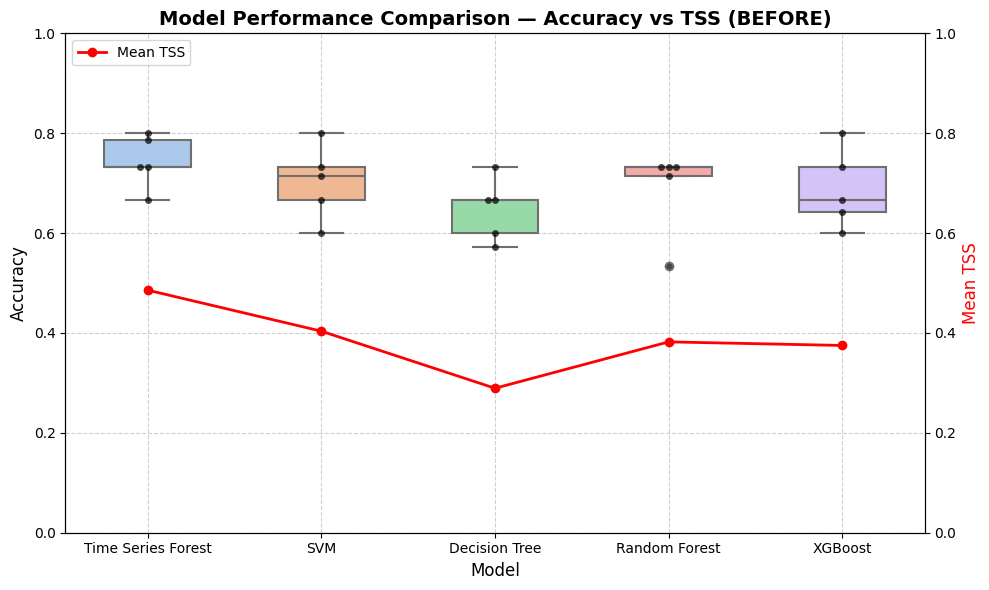

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

accuracy_values = {
    'Time Series Forest': [0.6666666667, 0.7333333333, 0.7333333333, 0.8, 0.7857142857],
    'SVM': [0.7333333333, 0.6, 0.6666666667, 0.8, 0.7142857143],
    'Decision Tree': [0.6666666667, 0.7333333333, 0.6, 0.6666666667, 0.5714285714],
    'Random Forest': [0.5333333333, 0.7333333333, 0.7333333333, 0.7333333333, 0.7142857143],
    'XGBoost': [0.6666666667, 0.8, 0.6, 0.7333333333, 0.6428571428]
}

mean_tss = {
    'Time Series Forest': 0.48571428571428577,
    'SVM': 0.4035714285714286,
    'Decision Tree': 0.2892857142857143,
    'Random Forest': 0.3821428571428572,
    'XGBoost': 0.37500000000000006
}

# Convert accuracy data for seaborn
df = pd.DataFrame(accuracy_values)
df_long = df.melt(var_name='Model', value_name='Accuracy')

# Create figure and dual-axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Boxplot and swarm for Accuracy (Left Axis)
sns.boxplot(data=df_long, x='Model', y='Accuracy', ax=ax1, palette='pastel', width=0.5, linewidth=1.5)
sns.swarmplot(data=df_long, x='Model', y='Accuracy', color='black', alpha=0.7, size=5, ax=ax1)

ax1.set_ylim(0.0, 1.0)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_xlabel('Model', fontsize=12)
ax1.set_title('Model Performance Comparison — Accuracy vs TSS (BEFORE)', fontsize=14, weight='bold')

# Create second y-axis for TSS (Right Axis)
ax2 = ax1.twinx()
ax2.plot(list(mean_tss.keys()), list(mean_tss.values()), color='red', marker='o', linestyle='-', linewidth=2, label='Mean TSS')
ax2.set_ylabel('Mean TSS', color='red', fontsize=12)
ax2.set_ylim(0.0, 1.0)

ax1.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()


C:\Users\shiva\AppData\Local\Temp\ipykernel_29896\1438088465.py:54: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(data=df_combined, x='Model', y='Accuracy', hue='Stage', dodge=True, color='black', alpha=0.7, size=4, ax=ax1)


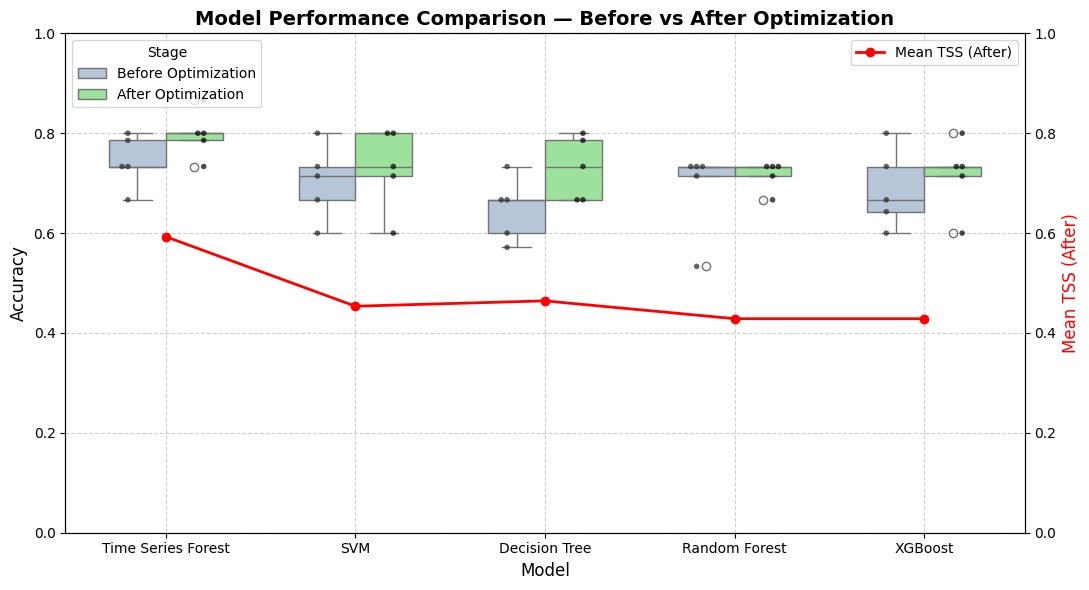

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# === BEFORE OPTIMIZATION ===
accuracy_before = {
    'Time Series Forest': [0.6666666667, 0.7333333333, 0.7333333333, 0.8, 0.7857142857],
    'SVM': [0.7333333333, 0.6, 0.6666666667, 0.8, 0.7142857143],
    'Decision Tree': [0.6666666667, 0.7333333333, 0.6, 0.6666666667, 0.5714285714],
    'Random Forest': [0.5333333333, 0.7333333333, 0.7333333333, 0.7333333333, 0.7142857143],
    'XGBoost': [0.6666666667, 0.8, 0.6, 0.7333333333, 0.6428571428]
}

mean_tss_before = {
    'Time Series Forest': 0.48571428571428577,
    'SVM': 0.4035714285714286,
    'Decision Tree': 0.2892857142857143,
    'Random Forest': 0.3821428571428572,
    'XGBoost': 0.37500000000000006
}

# === AFTER OPTIMIZATION ===
accuracy_after = {
    'Time Series Forest': [0.7333333333, 0.8, 0.8666666667, 0.8, 0.7857142857],
    'SVM': [0.8, 0.7333333333, 0.6, 0.8, 0.7142857143],
    'Decision Tree': [0.7333333333, 0.8, 0.6666666667, 0.6666666667, 0.7857142857],
    'Random Forest': [0.7333333333, 0.6666666667, 0.7333333333, 0.7333333333, 0.7142857143],
    'XGBoost': [0.7333333333, 0.8, 0.6, 0.7333333333, 0.7142857143]
}

mean_tss_after = {
    'Time Series Forest': 0.5928571428571429,
    'SVM': 0.45357142857142857,
    'Decision Tree': 0.46428571428571425,
    'Random Forest': 0.42857142857142855,
    'XGBoost': 0.42857142857142855
}

# Prepare DataFrame for seaborn
df_before = pd.DataFrame(accuracy_before).melt(var_name='Model', value_name='Accuracy')
df_before['Stage'] = 'Before Optimization'

df_after = pd.DataFrame(accuracy_after).melt(var_name='Model', value_name='Accuracy')
df_after['Stage'] = 'After Optimization'

df_combined = pd.concat([df_before, df_after])

# Create figure and axes
fig, ax1 = plt.subplots(figsize=(11, 6))

# Boxplot grouped by optimization stage
sns.boxplot(data=df_combined, x='Model', y='Accuracy', hue='Stage', palette=['#b0c4de', '#90ee90'], width=0.6, ax=ax1)
sns.swarmplot(data=df_combined, x='Model', y='Accuracy', hue='Stage', dodge=True, color='black', alpha=0.7, size=4, ax=ax1)

# Adjust hue legend (avoid duplicate)
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles[:2], labels[:2], title='Stage', loc='upper left')

ax1.set_ylim(0.0, 1.0)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_xlabel('Model', fontsize=12)
ax1.set_title('Model Performance Comparison — Before vs After Optimization', fontsize=14, weight='bold')

# Add Mean TSS (after optimization) on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(list(mean_tss_after.keys()), list(mean_tss_after.values()),
         color='red', marker='o', linestyle='-', linewidth=2, label='Mean TSS (After)')
ax2.set_ylabel('Mean TSS (After)', color='red', fontsize=12)
ax2.set_ylim(0.0, 1.0)
ax2.legend(loc='upper right')

# Grid and layout
ax1.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


C:\Users\shiva\AppData\Local\Temp\ipykernel_29896\3680089368.py:55: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(data=df_combined, x='Model', y='Accuracy', hue='Stage',


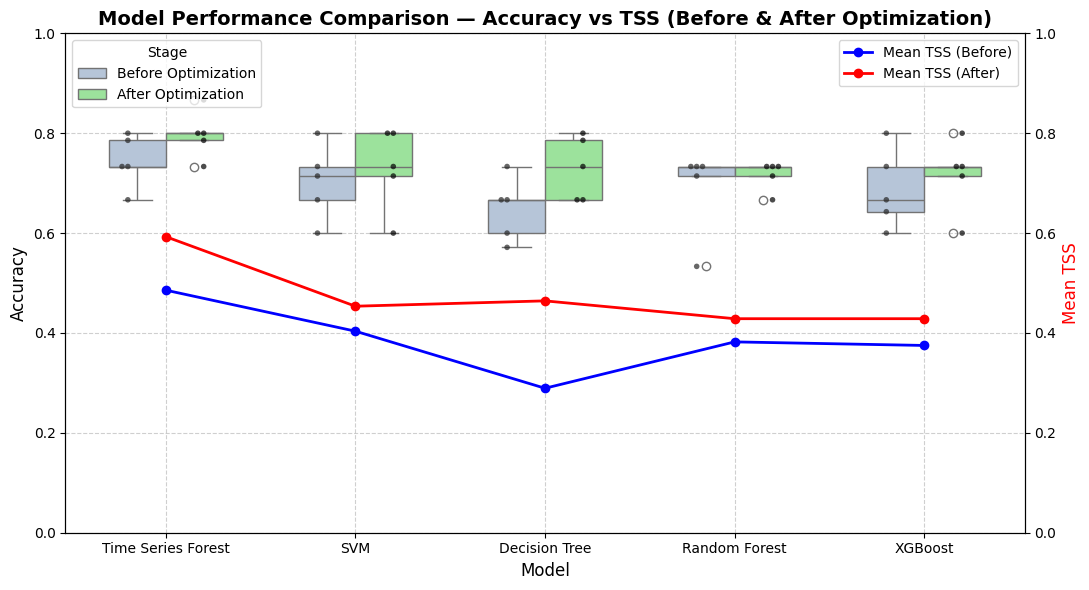

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# === BEFORE OPTIMIZATION ===
accuracy_before = {
    'Time Series Forest': [0.6666666667, 0.7333333333, 0.7333333333, 0.8, 0.7857142857],
    'SVM': [0.7333333333, 0.6, 0.6666666667, 0.8, 0.7142857143],
    'Decision Tree': [0.6666666667, 0.7333333333, 0.6, 0.6666666667, 0.5714285714],
    'Random Forest': [0.5333333333, 0.7333333333, 0.7333333333, 0.7333333333, 0.7142857143],
    'XGBoost': [0.6666666667, 0.8, 0.6, 0.7333333333, 0.6428571428]
}

mean_tss_before = {
    'Time Series Forest': 0.48571428571428577,
    'SVM': 0.4035714285714286,
    'Decision Tree': 0.2892857142857143,
    'Random Forest': 0.3821428571428572,
    'XGBoost': 0.37500000000000006
}

# === AFTER OPTIMIZATION ===
accuracy_after = {
    'Time Series Forest': [0.7333333333, 0.8, 0.8666666667, 0.8, 0.7857142857],
    'SVM': [0.8, 0.7333333333, 0.6, 0.8, 0.7142857143],
    'Decision Tree': [0.7333333333, 0.8, 0.6666666667, 0.6666666667, 0.7857142857],
    'Random Forest': [0.7333333333, 0.6666666667, 0.7333333333, 0.7333333333, 0.7142857143],
    'XGBoost': [0.7333333333, 0.8, 0.6, 0.7333333333, 0.7142857143]
}

mean_tss_after = {
    'Time Series Forest': 0.5928571428571429,
    'SVM': 0.45357142857142857,
    'Decision Tree': 0.46428571428571425,
    'Random Forest': 0.42857142857142855,
    'XGBoost': 0.42857142857142855
}

# Prepare DataFrame for seaborn
df_before = pd.DataFrame(accuracy_before).melt(var_name='Model', value_name='Accuracy')
df_before['Stage'] = 'Before Optimization'

df_after = pd.DataFrame(accuracy_after).melt(var_name='Model', value_name='Accuracy')
df_after['Stage'] = 'After Optimization'

df_combined = pd.concat([df_before, df_after])

# Create figure and axes
fig, ax1 = plt.subplots(figsize=(11, 6))

# Boxplot grouped by optimization stage
sns.boxplot(data=df_combined, x='Model', y='Accuracy', hue='Stage',
            palette=['#b0c4de', '#90ee90'], width=0.6, ax=ax1)
sns.swarmplot(data=df_combined, x='Model', y='Accuracy', hue='Stage',
              dodge=True, color='black', alpha=0.7, size=4, ax=ax1)

# Adjust legend (avoid duplicates)
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles[:2], labels[:2], title='Stage', loc='upper left')

ax1.set_ylim(0.0, 1.0)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_xlabel('Model', fontsize=12)
ax1.set_title('Model Performance Comparison — Accuracy vs TSS (Before & After Optimization)', fontsize=14, weight='bold')

# Add Mean TSS (before & after) on secondary y-axis
ax2 = ax1.twinx()

# Blue dashed line = Before Optimization
ax2.plot(list(mean_tss_before.keys()), list(mean_tss_before.values()),
         color='blue', marker='o', linestyle='-', linewidth=2, label='Mean TSS (Before)')

# Red solid line = After Optimization
ax2.plot(list(mean_tss_after.keys()), list(mean_tss_after.values()),
         color='red', marker='o', linestyle='-', linewidth=2, label='Mean TSS (After)')

ax2.set_ylabel('Mean TSS', color='red', fontsize=12)
ax2.set_ylim(0.0, 1.0)
ax2.legend(loc='upper right')

# Grid and layout
ax1.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [146]:
# for Ensemble

In [147]:
import pandas as pd

In [148]:
SEP_df = pd.read_csv("data/SEP_data_100MeV_Uni.csv", header = 0, index_col=0)
# SEP_df = SEP_df.drop([78, 79, 80, 81])
# column names and df index

In [149]:
NSEP_df_78 = pd.read_csv("data/NSEP_data_P2_Uni.csv", header = 0, index_col=0)
# NSEP_df_78 = NSEP_df_78.drop([78, 79, 80, 80])

In [150]:
# data = SEP_df.append(NSEP_df_78) # append the two SEP and NSEP dataframes
data = pd.concat([SEP_df, NSEP_df_78], axis=0)

In [151]:
data = data.reset_index(drop = True)

In [152]:
NSEP_start_index = len(SEP_df) + 1

In [153]:
data['event'] = 'SEP'
data.loc[NSEP_start_index:,['event']] = 'NSEP'
my_data_all = data
my_data_all

,1,2,3,4,5,6,7,8,9,10,...,63,64,65,66,67,68,69,70,71,event
0,0.00486,0.00412,0.00509,0.00546,0.00564,0.00509,0.00673,0.00644,0.00644,0.00442,...,0.00681,0.00479,0.00561,0.00586,0.00592,0.00465,0.00543,0.00598,0.00546,SEP
1,0.00509,0.00470,0.00471,0.00501,0.00463,0.00630,0.00546,0.00506,0.00569,0.00442,...,0.00516,0.00479,0.00524,0.00506,0.00486,0.00555,0.00506,0.00630,0.00540,SEP
2,0.00411,0.00465,0.00492,0.00516,0.00546,0.00524,0.00509,0.00465,0.00397,0.00427,...,0.00427,0.00434,0.00494,0.00465,0.00499,0.00614,0.00389,0.00419,0.00470,SEP
3,0.00434,0.00374,0.00441,0.00465,0.00442,0.00499,0.00386,0.00442,0.00465,0.00434,...,0.00398,0.00427,0.00501,0.00501,0.00388,0.00337,0.00449,0.00456,0.00494,SEP
4,0.00614,0.00434,0.00427,0.00434,0.00434,0.00465,0.00564,0.00397,0.00486,0.00442,...,0.00397,0.00398,0.00344,0.00397,0.00367,0.00448,0.00465,0.00442,0.00485,SEP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,0.00292,0.00318,0.00314,0.00217,0.00304,0.00277,0.00292,0.00247,0.00333,0.00314,...,0.00268,0.00307,0.00187,0.00304,0.00247,0.00239,0.00304,0.00329,0.00262,NSEP
70,0.00247,0.00246,0.00374,0.00329,0.00329,0.00311,0.00195,0.00329,0.00275,0.00277,...,0.00246,0.00277,0.00329,0.00188,0.00224,0.00269,0.00292,0.00246,0.00337,NSEP
71,0.00262,0.00362,0.00262,0.00284,0.00289,0.00239,0.00322,0.00165,0.00268,0.00292,...,0.00299,0.00292,0.00239,0.00275,0.00284,0.00232,0.00268,0.00292,0.00284,NSEP
72,0.00254,0.00307,0.00311,0.00284,0.00269,0.00217,0.00217,0.00247,0.00254,0.00326,...,0.00210,0.00318,0.00217,0.00239,0.00333,0.00254,0.00307,0.00333,0.00277,NSEP


In [154]:
from sklearn.model_selection import StratifiedKFold



y_TS = my_data_all.pop('event')
X_TS = my_data_all

# Tabular

In [29]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load data
sep_data = pd.read_csv("SEP_Tabular_6h.csv")
nsep_data = pd.read_csv("NSEP_Tabular_6h.csv")

# Add target labels
sep_data['label'] = 'SEP'
nsep_data['label'] = 'NSEP'

# Concatenate dataframes
data = pd.concat([sep_data, nsep_data])

# Extract features and target
X = data[['Sunspots', 'AR', 'Flare Class']]
y = data['label']

# Extract Flare Class types without intensities
X['Flare Class'] = X['Flare Class'].str.extract(r'([A-Z])')

# Create dummy variables for Flare Class
flare_dummies = pd.get_dummies(X['Flare Class'], prefix='Flare')
X = pd.concat([X[['Sunspots', 'AR']], flare_dummies], axis=1)

print(X)

# Initialize SVM classifier
svm_classifier = SVC(kernel='linear')

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# List to store accuracy values
accuracy_values_SVM = []

# Perform 5-fold cross-validation
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train the classifier
    svm_classifier.fit(X_train, y_train)

    # Make predictions
    y_pred = svm_classifier.predict(X_test)

    # Evaluate the accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Append accuracy value to the list
    accuracy_values_SVM.append(accuracy)

# Calculate the mean accuracy
mean_accuracy = sum(accuracy_values_SVM) / len(accuracy_values_SVM)
print("Mean Accuracy:", mean_accuracy)

# Print all accuracy values
print("All Accuracy Values:", accuracy_values_SVM)


    Sunspots  AR  Flare_C  Flare_M  Flare_X
0         28  15        0        0        1
1         23   7        0        0        1
2          8   6        0        1        0
3         26   9        0        0        1
4         19  20        1        0        0
..       ...  ..      ...      ...      ...
28        30  16        1        0        0
29        22  15        0        1        0
30        44  25        1        0        0
31        21  15        1        0        0
32        23  22        0        0        1

[70 rows x 5 columns]
Mean Accuracy: 0.7142857142857143
All Accuracy Values: [0.6428571428571429, 0.7857142857142857, 0.7142857142857143, 0.7142857142857143, 0.7142857142857143]


C:\Users\shiva\AppData\Local\Temp\ipykernel_29896\844884294.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Flare Class'] = X['Flare Class'].str.extract(r'([A-Z])')


In [30]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

# Load data
sep_data = pd.read_csv("data/SEP_Tabular_6h.csv")
nsep_data = pd.read_csv("data/NSEP_Tabular_6h.csv")

# Add target labels
sep_data['label'] = 'SEP'
nsep_data['label'] = 'NSEP'

# Concatenate dataframes
data = pd.concat([sep_data, nsep_data])

# Extract features and target
X = data[['Sunspots', 'AR', 'Flare Class']]
y = data['label']

# Extract flare class letters
X['Flare Class'] = X['Flare Class'].str.extract(r'([A-Z])')

# One-hot encode flare classes
flare_dummies = pd.get_dummies(X['Flare Class'], prefix='Flare')
X = pd.concat([X[['Sunspots', 'AR']], flare_dummies], axis=1)

# Initialize classifier
# rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier = RandomForestClassifier(n_estimators=50, max_depth=6, min_samples_split=4,
                                       min_samples_leaf=3, max_features="sqrt", class_weight="balanced",
                                       random_state=42)

# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics lists
accuracy_values_RF = []
f1_scores_RF = []
tss_scores_RF = []
hss_scores_RF = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    rf_classifier.fit(X_train, y_train)
    y_pred = rf_classifier.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    tss = (tp / (tp + fn)) - (fp / (fp + tn))
    hss = (2 * ((tp * tn) - (fn * fp))) / (((tp + fn) * (fn + tn)) + ((fp + tn) * (tp + fp)))

    accuracy_values_RF.append(accuracy)
    f1_scores_RF.append(f1)
    tss_scores_RF.append(tss)
    hss_scores_RF.append(hss)

# Results
print("\nRandom Forest Results:")
print("Mean Accuracy:", sum(accuracy_values_RF)/len(accuracy_values_RF))
print("Mean F1 Score:", sum(f1_scores_RF)/len(f1_scores_RF))
print("Mean TSS:", sum(tss_scores_RF)/len(tss_scores_RF))
print("Mean HSS:", sum(hss_scores_RF)/len(hss_scores_RF))
print("All Accuracy Values:", accuracy_values_RF)

# Before modifying Parameters
# Random Forest Results:
# Mean Accuracy: 0.621904761904762
# Mean F1 Score: 0.6178347578347578
# Mean TSS: 0.23571428571428577
# Mean HSS: 0.23738650729801175
# All Accuracy Values: [0.6666666666666666, 0.7333333333333333, 0.6, 0.4666666666666667, 0.6428571428571429]

#AFTER
# Random Forest Results:
# Mean Accuracy: 0.7171428571428572
# Mean F1 Score: 0.7145098039215687
# Mean TSS: 0.43571428571428567
# Mean HSS: 0.4344300822561692
# All Accuracy Values: [0.6666666666666666, 0.6666666666666666, 0.8666666666666667, 0.6, 0.7857142857142857]

C:\Users\shiva\AppData\Local\Temp\ipykernel_29896\1845584558.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Flare Class'] = X['Flare Class'].str.extract(r'([A-Z])')



Random Forest Results:
Mean Accuracy: 0.7171428571428572
Mean F1 Score: 0.7145098039215687
Mean TSS: 0.43571428571428567
Mean HSS: 0.4344300822561692
All Accuracy Values: [0.6666666666666666, 0.6666666666666666, 0.8666666666666667, 0.6, 0.7857142857142857]


In [31]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix
from itertools import product

# === Load and prepare data ===
sep_data = pd.read_csv("data/SEP_Tabular_6h.csv")
nsep_data = pd.read_csv("data/NSEP_Tabular_6h.csv")

# Label data
sep_data['label'] = 'SEP'
nsep_data['label'] = 'NSEP'

# Combine data
data = pd.concat([sep_data, nsep_data])
X = data[['Sunspots', 'AR', 'Flare Class']]
y = data['label']

# Extract flare class (A/B/C/M/X)
X['Flare Class'] = X['Flare Class'].str.extract(r'([A-Z])')

# Convert flare class to dummy variables
flare_dummies = pd.get_dummies(X['Flare Class'], prefix='Flare')
X = pd.concat([X[['Sunspots', 'AR']], flare_dummies], axis=1)

# === Define parameter grid ===
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [200, 500],
    'class_weight': [None, 'balanced']
}

# === Generate all combinations ===
param_combinations = list(product(
    param_grid_lr['C'],
    param_grid_lr['penalty'],
    param_grid_lr['solver'],
    param_grid_lr['max_iter'],
    param_grid_lr['class_weight']
))

results = []

# === 5-fold cross-validation setup ===
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# === Grid search loop ===
for i, (C, penalty, solver, max_iter, class_weight) in enumerate(param_combinations):
    acc_scores, tss_scores, hss_scores = [], [], []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        try:
            model = LogisticRegression(
                C=C,
                penalty=penalty,
                solver=solver,
                max_iter=max_iter,
                class_weight=class_weight
            )
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Accuracy
            acc = accuracy_score(y_test, y_pred)
            acc_scores.append(acc)

            # Confusion matrix
            tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=['NSEP', 'SEP']).ravel()

            # TSS
            tss = (tp / (tp + fn)) - (fp / (fp + tn))
            tss_scores.append(tss)

            # HSS
            hss = (2 * ((tp * tn) - (fn * fp))) / (
                ((tp + fn) * (fn + tn)) + ((fp + tn) * (tp + fp))
            )
            hss_scores.append(hss)
        except Exception as e:
            print(f"⚠️ Skipped combination {i} due to error: {e}")
            continue

    results.append({
        'C': C,
        'penalty': penalty,
        'solver': solver,
        'max_iter': max_iter,
        'class_weight': class_weight,
        'Mean Accuracy': np.mean(acc_scores),
        'Mean TSS': np.mean(tss_scores),
        'Mean HSS': np.mean(hss_scores)
    })

# === Results summary ===
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Mean Accuracy', ascending=False)

# Display top 10
print("\nTop 10 Logistic Regression Configurations:\n")
print(results_df.head(10).to_string(index=False))


C:\Users\shiva\AppData\Local\Temp\ipykernel_29896\561019613.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Flare Class'] = X['Flare Class'].str.extract(r'([A-Z])')



Top 10 Logistic Regression Configurations:

  C penalty    solver  max_iter class_weight  Mean Accuracy  Mean TSS  Mean HSS
1.0      l2 liblinear       200     balanced       0.716190  0.428571  0.430464
1.0      l2 liblinear       500     balanced       0.716190  0.428571  0.430464
1.0      l2     lbfgs       200         None       0.716190  0.428571  0.430464
1.0      l2     lbfgs       200     balanced       0.716190  0.428571  0.430464
1.0      l2     lbfgs       500         None       0.716190  0.428571  0.430464
1.0      l2     lbfgs       500     balanced       0.716190  0.428571  0.430464
1.0      l2 liblinear       200         None       0.702857  0.403571  0.404402
1.0      l2 liblinear       500         None       0.702857  0.403571  0.404402
0.1      l2 liblinear       200     balanced       0.688571  0.375000  0.374467
0.1      l2 liblinear       500     balanced       0.688571  0.375000  0.374467


C:\Users\shiva\AppData\Local\Temp\ipykernel_29896\1141960216.py:34: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.swarmplot(data=df_combined, x='Model', y='Accuracy', hue='Stage',


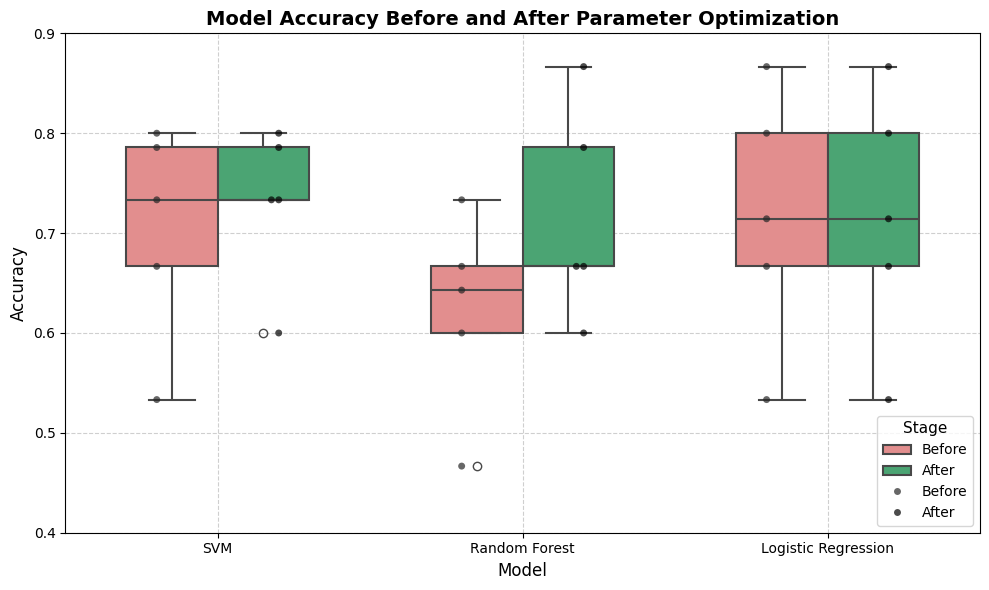

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data_before = {
    'Model': ['SVM'] * 5 + ['Random Forest'] * 5 + ['Logistic Regression'] * 5,
    'Stage': ['Before'] * 15,
    'Accuracy': [
        0.6667, 0.7333, 0.8, 0.5333, 0.7857,              # SVM
        0.6667, 0.7333, 0.6, 0.4667, 0.6429,              # Random Forest
        0.6667, 0.8, 0.8667, 0.5333, 0.7143               # Logistic Regression
    ]
}

data_after = {
    'Model': ['SVM'] * 5 + ['Random Forest'] * 5 + ['Logistic Regression'] * 5,
    'Stage': ['After'] * 15,
    'Accuracy': [
        0.7333, 0.7333, 0.8, 0.6, 0.7857,                 # SVM
        0.6667, 0.6667, 0.8667, 0.6, 0.7857,              # Random Forest
        0.6667, 0.8, 0.8667, 0.5333, 0.7143               # Logistic Regression
    ]
}

df_before = pd.DataFrame(data_before)
df_after = pd.DataFrame(data_after)
df_combined = pd.concat([df_before, df_after])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_combined, x='Model', y='Accuracy', hue='Stage',
            palette={'Before': 'lightcoral', 'After': 'mediumseagreen'},
            width=0.6, linewidth=1.5)

sns.swarmplot(data=df_combined, x='Model', y='Accuracy', hue='Stage',
              dodge=True, color='black', alpha=0.7, size=5)

plt.title('Model Accuracy Before and After Parameter Optimization', fontsize=14, weight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0.4, 0.9)
plt.legend(title='Stage', title_fontsize=11, fontsize=10, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()


In [33]:
# for Ensemble

import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load data
sep_data = pd.read_csv("data/SEP_Tabular_6h.csv")
nsep_data = pd.read_csv("data/NSEP_Tabular_6h.csv")

# Add target labels
sep_data['label'] = 'SEP'
nsep_data['label'] = 'NSEP'

# Concatenate dataframes
data = pd.concat([sep_data, nsep_data])

# Extract features and target
X = data[['Sunspots', 'AR', 'Flare Class']]
y = data['label']

# Extract Flare Class types without intensities
X['Flare Class'] = X['Flare Class'].str.extract(r'([A-Z])')

# Create dummy variables for Flare Class
flare_dummies = pd.get_dummies(X['Flare Class'], prefix='Flare')
X = pd.concat([X[['Sunspots', 'AR']], flare_dummies], axis=1)


C:\Users\shiva\AppData\Local\Temp\ipykernel_29896\999353363.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Flare Class'] = X['Flare Class'].str.extract(r'([A-Z])')


# Ensemble (TS + Polygons)

In [44]:
print("len(X):", len(X))
print("len(X_AR_HOG):", len(X_AR_HOG))
print("len(X_TS):", len(X_TS))

len(X): 49
len(X_AR_HOG): 49
len(X_TS): 74


In [45]:
def compute_tss(y_true, y_prob, threshold):
    """
    y_true: ground truth labels (0/1)
    y_prob: predicted probability for class 1
    threshold: decision threshold
    """
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Avoid division by zero
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    return tpr - fpr


In [104]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sktime.classification.interval_based import TimeSeriesForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

best_thresholds = []
positive_rates = []
tss_per_fold = []

# Define models
# image_model = RandomForestClassifier(n_estimators=80, random_state=42)
# ts_model = TimeSeriesForestClassifier(n_estimators=100, random_state=42)
image_model = RandomForestClassifier(n_estimators=25, max_depth=None, max_features='sqrt',
                                        min_samples_leaf=1, min_samples_split=9,
                                        bootstrap=True, random_state=42)
                                        #time series
ts_model = TimeSeriesForestClassifier(min_interval=5, n_estimators=200, n_jobs=-1, random_state=42)


# Setup for cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ensemble_accuracy_scores_TS_Pol = []
precision_scores = []
recall_scores = []
f1_scores = []
auc_scores = []

for train_index, test_index in skf.split(X_AR_HOG, y_AR_HOG):
    # Splitting data for both models
    X_img_train, X_img_test = X_AR_HOG[train_index], X_AR_HOG[test_index]
    X_ts_train, X_ts_test = X_TS.iloc[train_index], X_TS.iloc[test_index]
    y_train, y_test = y_AR_HOG[train_index], y_AR_HOG[test_index]

    # Train models
    image_model.fit(X_img_train, y_train)
    ts_model.fit(X_ts_train.to_numpy(), y_train)

    # Get probability predictions from each model
    proba_img = image_model.predict_proba(X_img_test)
    proba_ts = ts_model.predict_proba(X_ts_test.to_numpy())

    # Average the probabilities from both models
    # average_proba = (proba_img + proba_ts) / 2

    # Convert averaged probabilities to final predictions
    # final_predictions = np.argmax(average_proba, axis=1)

    # Calculate metrics
    #acc = accuracy_score(y_test, final_predictions)

    average_proba = (proba_img + proba_ts) / 2

    # Probability for the positive SEP
    sep_probs = average_proba[:, 1]

    # Searching the thresholds
    thresholds = np.linspace(0.0, 1.0, 101)
    tss_scores = []

    min_pos_rate = 0.05
    max_pos_rate = 0.95

    tss_scores = []
    acc_scores = []

    for th in thresholds:
        y_pred = (sep_probs >= th).astype(int)
        pos_rate = y_pred.mean()

        if pos_rate < min_pos_rate or pos_rate > max_pos_rate:
            tss_scores.append(-np.inf)
            acc_scores.append(-np.inf)
            continue

        tss = compute_tss(y_test, sep_probs, th)
        acc = accuracy_score(y_test, y_pred)

        tss_scores.append(tss)
        acc_scores.append(acc)


    best_threshold = thresholds[np.argmax(tss_scores)]
    best_tss = np.max(tss_scores)

    best_thresholds.append(best_threshold)
    tss_per_fold.append(best_tss)

    final_predictions = (sep_probs >= best_threshold).astype(int)

    positive_rates.append(final_predictions.mean())

    acc = accuracy_score(y_test, final_predictions)
    prec = precision_score(y_test, final_predictions, average='macro')
    rec = recall_score(y_test, final_predictions, average='macro')
    f1 = f1_score(y_test, final_predictions, average='macro')
    auc = roc_auc_score(y_test, average_proba[:, 1], multi_class='ovo')

    # Append results
    ensemble_accuracy_scores_TS_Pol.append(acc)
    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)
    auc_scores.append(auc)

# Output the mean of the collected scores
print(f"Mean Accuracy: {np.mean(ensemble_accuracy_scores_TS_Pol) * 100:.2f}%")
print(f"Mean Precision: {np.mean(precision_scores) * 100:.2f}%")
print(f"Mean Recall: {np.mean(recall_scores) * 100:.2f}%")
print(f"Mean F1-Score: {np.mean(f1_scores) * 100:.2f}%")
print(f"Mean AUC: {np.mean(auc_scores):.2f}")

print("Best thresholds per fold:", best_thresholds)
print("Mean threshold:", np.mean(best_thresholds))
print("Positive prediction rates per fold:", positive_rates)
print("Mean positive rate:", np.mean(positive_rates))
print("TSS per fold:", tss_per_fold)
print("Mean TSS:", np.mean(tss_per_fold))

# Print a full classification report for the last fold as an example
print("\nClassification Report for the last fold:")
print(classification_report(y_test, final_predictions))


Mean Accuracy: 77.11%
Mean Precision: 84.00%
Mean Recall: 76.33%
Mean F1-Score: 74.46%
Mean AUC: 0.74
Best thresholds per fold: [0.72, 0.32, 0.54, 0.41000000000000003, 0.65]
Mean threshold: 0.528
Positive prediction rates per fold: [0.5, 0.8, 0.5, 0.8, 0.1111111111111111]
Mean positive rate: 0.5422222222222223
TSS per fold: [0.6000000000000001, 0.5, 0.8333333333333334, 0.5, 0.2]
Mean TSS: 0.5266666666666667

Classification Report for the last fold:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         4
           1       1.00      0.20      0.33         5

    accuracy                           0.56         9
   macro avg       0.75      0.60      0.50         9
weighted avg       0.78      0.56      0.48         9



In [48]:
print("len(X):", len(X))
print("len(X_AR_HOG):", len(X_AR_HOG))
print("len(X_TS):", len(X_TS))

len(X): 49
len(X_AR_HOG): 49
len(X_TS): 74


# Ensemble (TS + Tabular)

In [113]:
print("len(X):", len(X))
print("len(X_AR_HOG):", len(X_AR_HOG))
print("len(X_TS):", len(X_TS))

len(X): 49
len(X_AR_HOG): 49
len(X_TS): 74


In [114]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sktime.classification.interval_based import TimeSeriesForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

best_thresholds = []
positive_rates = []
tss_per_fold = []

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # Transform labels to numeric

# Define models
# image_model = RandomForestClassifier(n_estimators=80, random_state=42)
ts_model = TimeSeriesForestClassifier(n_estimators=80, random_state=42)
svm_model = SVC(probability=True, kernel='linear', random_state=42)

# Setup for cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ensemble_accuracy_scores_TS_Tab = []  # To store ensemble accuracy only

for train_index, test_index in skf.split(X, y_encoded):
    # Image and time series data assumed to be split here
    X_img_train, X_img_test = X_AR_HOG[train_index], X_AR_HOG[test_index]
    X_ts_train, X_ts_test = X_TS.iloc[train_index], X_TS.iloc[test_index]
    X_tab = np.array(X)
    X_tab_train, X_tab_test = X_tab[train_index], X_tab[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    # Train models
    # image_model.fit(X_img_train, y_train)
    ts_model.fit(X_ts_train.to_numpy(), y_train)
    svm_model.fit(X_tab_train, y_train)

    # Get probability predictions from each model
    # proba_img = image_model.predict_proba(X_img_test)
    proba_ts = ts_model.predict_proba(X_ts_test.to_numpy())
    proba_svm = svm_model.predict_proba(X_tab_test)

    # Average the probabilities from all models
    # average_proba = (proba_ts + proba_svm) / 2

    # # Convert averaged probabilities to final predictions
    # final_predictions = np.argmax(average_proba, axis=1)

    # # Calculate and store ensemble accuracy
    # ensemble_accuracy = accuracy_score(y_test, final_predictions)

    average_proba = (proba_ts + proba_svm) / 2

    # Probability for the positive SEP
    sep_probs = average_proba[:, 1]

    # Searching the thresholds
    thresholds = np.linspace(0.0, 1.0, 101)
    tss_scores = []

    min_pos_rate = 0.05
    max_pos_rate = 0.95

    tss_scores = []
    acc_scores = []

    for th in thresholds:
        y_pred = (sep_probs >= th).astype(int)
        pos_rate = y_pred.mean()

        if pos_rate < min_pos_rate or pos_rate > max_pos_rate:
            tss_scores.append(-np.inf)
            acc_scores.append(-np.inf)
            continue

        tss = compute_tss(y_test, sep_probs, th)
        acc = accuracy_score(y_test, y_pred)

        tss_scores.append(tss)
        acc_scores.append(acc)

    best_threshold = thresholds[np.argmax(tss_scores)]
    best_tss = np.max(tss_scores)

    best_thresholds.append(best_threshold)
    tss_per_fold.append(best_tss)

    # compute final predictions
    final_predictions = (sep_probs >= best_threshold).astype(int)

    positive_rates.append(final_predictions.mean())

    #final_predictions = (sep_probs >= best_threshold).astype(int)

    ensemble_accuracy = accuracy_score(y_test, final_predictions)
    ensemble_accuracy_scores_TS_Tab.append(ensemble_accuracy)

average_ensemble_accuracy = np.mean(ensemble_accuracy_scores_TS_Tab)
print(f"Average Ensemble Accuracy: {average_ensemble_accuracy * 100:.2f}%")

print("Best thresholds per fold:", best_thresholds)
print("Mean threshold:", np.mean(best_thresholds))
print("Positive prediction rates per fold:", positive_rates)
print("Mean positive rate:", np.mean(positive_rates))
print("TSS per fold:", tss_per_fold)
print("Mean TSS:", np.mean(tss_per_fold))

# # Plotting the ensemble accuracy
# plt.figure(figsize=(10, 6))
# plt.boxplot(ensemble_accuracy_scores, patch_artist=True, boxprops=dict(facecolor='skyblue'), medianprops=dict(color='orange'))
# plt.title('Ensemble Accuracy for Combined Classifiers')
# plt.xticks([1], ['Ensemble (RF + TSF + SVM)'])
# plt.ylabel('Accuracy')
# plt.ylim(0.5, 1.0)  # Adjust based on the observed range of accuracy
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.show()


Average Ensemble Accuracy: 85.33%
Best thresholds per fold: [0.7000000000000001, 0.65, 0.5700000000000001, 0.71, 0.35000000000000003]
Mean threshold: 0.596
Positive prediction rates per fold: [0.5, 0.4, 0.6, 0.4, 0.6666666666666666]
Mean positive rate: 0.5133333333333333
TSS per fold: [1.0, 0.6666666666666666, 1.0, 0.6666666666666666, 0.30000000000000004]
Mean TSS: 0.7266666666666666


In [115]:
X = np.array(X)
print("X:", X.shape)
print("X_AR_HOG:", X_AR_HOG.shape)
print("X_TS:", X_TS.shape)
print("y_encoded:", len(y_encoded))


X: (49, 6480)
X_AR_HOG: (49, 6480)
X_TS: (74, 71)
y_encoded: 49


# Ensemble (Polygons + Tabular)

In [116]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sktime.classification.interval_based import TimeSeriesForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # Transform labels to numeric

# Define models
image_model = RandomForestClassifier(n_estimators=80, random_state=42)
# ts_model = TimeSeriesForestClassifier(n_estimators=80, random_state=42)
svm_model = SVC(probability=True, kernel='linear', random_state=42)

# Setup for cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ensemble_accuracy_scores_Pol_Tab = []  # To store ensemble accuracy only

for train_index, test_index in skf.split(X, y_encoded):
    # Image and time series data assumed to be split here
    X_img_train, X_img_test = X_AR_HOG[train_index], X_AR_HOG[test_index]
    X_ts_train, X_ts_test = X_TS.iloc[train_index], X_TS.iloc[test_index]
    #X_tab_train, X_tab_test = X.iloc[train_index], X.iloc[test_index]
    X_tab_train, X_tab_test = X[train_index], X[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    # Train models
    image_model.fit(X_img_train, y_train)
    # ts_model.fit(X_ts_train.to_numpy(), y_train)
    svm_model.fit(X_tab_train, y_train)

    # Get probability predictions from each model
    proba_img = image_model.predict_proba(X_img_test)
    # proba_ts = ts_model.predict_proba(X_ts_test.to_numpy())
    proba_svm = svm_model.predict_proba(X_tab_test)

    # Average the probabilities from all models
    # average_proba = (proba_img + proba_svm) / 2

    # # Convert averaged probabilities to final predictions
    # final_predictions = np.argmax(average_proba, axis=1)

    # # Calculate and store ensemble accuracy
    # ensemble_accuracy = accuracy_score(y_test, final_predictions)

    average_proba = (proba_img + proba_svm) / 2

    # Probability for the positive SEP
    sep_probs = average_proba[:, 1]

    # Searching the thresholds
    thresholds = np.linspace(0.0, 1.0, 101)
    tss_scores = []

    min_pos_rate = 0.05
    max_pos_rate = 0.95

    tss_scores = []
    acc_scores = []

    for th in thresholds:
        y_pred = (sep_probs >= th).astype(int)
        pos_rate = y_pred.mean()

        if pos_rate < min_pos_rate or pos_rate > max_pos_rate:
            tss_scores.append(-np.inf)
            acc_scores.append(-np.inf)
            continue

        tss = compute_tss(y_test, sep_probs, th)
        acc = accuracy_score(y_test, y_pred)

        tss_scores.append(tss)
        acc_scores.append(acc)

    best_threshold = thresholds[np.argmax(tss_scores)]
    best_tss = np.max(tss_scores)

    best_thresholds.append(best_threshold)
    tss_per_fold.append(best_tss)

    # compute final predictions
    final_predictions = (sep_probs >= best_threshold).astype(int)

    positive_rates.append(final_predictions.mean())

    ensemble_accuracy = accuracy_score(y_test, final_predictions)
    ensemble_accuracy_scores_Pol_Tab.append(ensemble_accuracy)

average_ensemble_accuracy = np.mean(ensemble_accuracy_scores_Pol_Tab)

print(f"Average Ensemble Accuracy: {average_ensemble_accuracy * 100:.2f}%")
print("Best thresholds per fold:", best_thresholds)
print("Mean threshold:", np.mean(best_thresholds))
print("Positive prediction rates per fold:", positive_rates)
print("Mean positive rate:", np.mean(positive_rates))
print("TSS per fold:", tss_per_fold)
print("Mean TSS:", np.mean(tss_per_fold))


Average Ensemble Accuracy: 81.56%
Best thresholds per fold: [0.7000000000000001, 0.65, 0.5700000000000001, 0.71, 0.35000000000000003, 0.58, 0.58, 0.55, 0.71, 0.52]
Mean threshold: 0.592
Positive prediction rates per fold: [0.5, 0.4, 0.6, 0.4, 0.6666666666666666, 0.5, 0.4, 0.6, 0.5, 0.3333333333333333]
Mean positive rate: 0.48999999999999994
TSS per fold: [1.0, 0.6666666666666666, 1.0, 0.6666666666666666, 0.30000000000000004, 1.0, 0.6666666666666666, 0.5833333333333334, 0.41666666666666663, 0.6]
Mean TSS: 0.69


# Ensemble (TS + Polygons + Tabular)

In [163]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sktime.classification.interval_based import TimeSeriesForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # Transform labels to numeric

# Define models
    #Polygon
image_model = RandomForestClassifier(n_estimators=25, max_depth=None, max_features='sqrt',
                                        min_samples_leaf=1, min_samples_split=9,
                                        bootstrap=True, random_state=42)
                                        #time series
ts_model = TimeSeriesForestClassifier(min_interval=5, n_estimators=200, n_jobs=-1, random_state=42)
    #Tabular
svm_model = RandomForestClassifier(n_estimators=50, max_depth=6, min_samples_split=4,
                                       min_samples_leaf=3, max_features="sqrt", class_weight="balanced",
                                       random_state=42)

# Setup for cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ensemble_accuracy_scores_TS_Pol_Tab = []  # To store ensemble accuracy only

for train_index, test_index in skf.split(X, y_encoded):
    # Image and time series data assumed to be split here
    X_img_train, X_img_test = X_AR_HOG[train_index], X_AR_HOG[test_index]
    X_ts_train, X_ts_test = X_TS.iloc[train_index], X_TS.iloc[test_index]
    X_tab = np.array(X)
    X_tab_train, X_tab_test = X_tab[train_index], X_tab[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    # Train models
    image_model.fit(X_img_train, y_train)
    ts_model.fit(X_ts_train.to_numpy(), y_train)
    svm_model.fit(X_tab_train, y_train)

    # Get probability predictions from each model
    proba_img = image_model.predict_proba(X_img_test)
    proba_ts = ts_model.predict_proba(X_ts_test.to_numpy())
    proba_svm = svm_model.predict_proba(X_tab_test)

    # # Average the probabilities from all models
    # average_proba = (proba_img + proba_ts + proba_svm) / 3

    # # Convert averaged probabilities to final predictions
    # final_predictions = np.argmax(average_proba, axis=1)

    # # Calculate and store ensemble accuracy
    # ensemble_accuracy = accuracy_score(y_test, final_predictions)

    average_proba = (proba_img + proba_ts + proba_svm) / 3

    # Probability for the positive SEP
    sep_probs = average_proba[:, 1]

    # Searching the thresholds
    thresholds = np.linspace(0.0, 1.0, 101)
    tss_scores = []

    min_pos_rate = 0.05
    max_pos_rate = 0.95

    tss_scores = []
    acc_scores = []

    for th in thresholds:
        y_pred = (sep_probs >= th).astype(int)
        pos_rate = y_pred.mean()

        if pos_rate < min_pos_rate or pos_rate > max_pos_rate:
            tss_scores.append(-np.inf)
            acc_scores.append(-np.inf)
            continue

        tss = compute_tss(y_test, sep_probs, th)
        acc = accuracy_score(y_test, y_pred)

        tss_scores.append(tss)
        acc_scores.append(acc)

    best_threshold = thresholds[np.argmax(tss_scores)]
    best_tss = np.max(tss_scores)

    final_predictions = (sep_probs >= best_threshold).astype(int)

    ensemble_accuracy = accuracy_score(y_test, final_predictions)
    ensemble_accuracy_scores_TS_Pol_Tab.append(ensemble_accuracy)

average_ensemble_accuracy = np.mean(ensemble_accuracy_scores_TS_Pol_Tab)
print(f"Average Ensemble Accuracy: {average_ensemble_accuracy * 100:.2f}%")

print("Best thresholds per fold:", best_thresholds)
print("Mean threshold:", np.mean(best_thresholds))
print("Positive prediction rates per fold:", positive_rates)
print("Mean positive rate:", np.mean(positive_rates))
print("TSS per fold:", tss_per_fold)
print("Mean TSS:", np.mean(tss_per_fold))

Average Ensemble Accuracy: 77.11%
Best thresholds per fold: [0.7000000000000001, 0.65, 0.5700000000000001, 0.71, 0.35000000000000003, 0.58, 0.58, 0.55, 0.71, 0.52]
Mean threshold: 0.592
Positive prediction rates per fold: [0.5, 0.4, 0.6, 0.4, 0.6666666666666666, 0.5, 0.4, 0.6, 0.5, 0.3333333333333333]
Mean positive rate: 0.48999999999999994
TSS per fold: [1.0, 0.6666666666666666, 1.0, 0.6666666666666666, 0.30000000000000004, 1.0, 0.6666666666666666, 0.5833333333333334, 0.41666666666666663, 0.6]
Mean TSS: 0.69


In [164]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sktime.classification.interval_based import TimeSeriesForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt



# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # Transform labels to numeric

# Define models
image_model = RandomForestClassifier(n_estimators=80, random_state=42)
ts_model = TimeSeriesForestClassifier(n_estimators=80, random_state=42)
svm_model = SVC(probability=True, kernel='linear', random_state=42)

# Setup for cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to store metrics
ensemble_accuracy_scores_TS_Pol_Tab = []
ensemble_f1_scores = []
ensemble_precision_scores = []
ensemble_recall_scores = []
ensemble_tss_scores = []
ensemble_hss_scores = []

for train_index, test_index in skf.split(X, y_encoded):
    # Image and time series data assumed to be split here
    X_img_train, X_img_test = X_AR_HOG[train_index], X_AR_HOG[test_index]
    X_ts_train, X_ts_test = X_TS.iloc[train_index], X_TS.iloc[test_index]
    X_tab = np.array(X)
    X_tab_train, X_tab_test = X_tab[train_index], X_tab[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    # Train models
    image_model.fit(X_img_train, y_train)
    ts_model.fit(X_ts_train.to_numpy(), y_train)
    svm_model.fit(X_tab_train, y_train)

    # Get probability predictions from each model
    proba_img = image_model.predict_proba(X_img_test)
    proba_ts = ts_model.predict_proba(X_ts_test.to_numpy())
    proba_svm = svm_model.predict_proba(X_tab_test)

    # Average the probabilities from all models
    # average_proba = (proba_img + proba_ts + proba_svm) / 3

    # # Convert averaged probabilities to final predictions
    # final_predictions = np.argmax(average_proba, axis=1)

    # # Calculate and store ensemble accuracy
    # ensemble_accuracy = accuracy_score(y_test, final_predictions)

    average_proba = (proba_img + proba_ts + proba_svm) / 3

    # Probability for the positive SEP
    sep_probs = average_proba[:, 1]

    # Searching the thresholds
    thresholds = np.linspace(0.0, 1.0, 101)
    tss_scores = []

    min_pos_rate = 0.05
    max_pos_rate = 0.95

    tss_scores = []
    acc_scores = []

    for th in thresholds:
        y_pred = (sep_probs >= th).astype(int)
        pos_rate = y_pred.mean()

        if pos_rate < min_pos_rate or pos_rate > max_pos_rate:
            tss_scores.append(-np.inf)
            acc_scores.append(-np.inf)
            continue

        tss = compute_tss(y_test, sep_probs, th)
        acc = accuracy_score(y_test, y_pred)

        tss_scores.append(tss)
        acc_scores.append(acc)
        
    best_threshold = thresholds[np.argmax(tss_scores)]
    best_tss = np.max(tss_scores)

    final_predictions = (sep_probs >= best_threshold).astype(int)

    ensemble_accuracy = accuracy_score(y_test, final_predictions)
    ensemble_accuracy_scores_TS_Pol_Tab.append(ensemble_accuracy)

    # Calculate F1 score and append to the list
    f1_ensemble = f1_score(y_test, final_predictions, average='weighted')
    ensemble_f1_scores.append(f1_ensemble)

    # Calculate precision and recall and append to the lists
    precision_ensemble = precision_score(y_test, final_predictions, average='macro')
    ensemble_precision_scores.append(precision_ensemble)
    recall_ensemble = recall_score(y_test, final_predictions, average='macro')
    ensemble_recall_scores.append(recall_ensemble)

    # Confusion matrix for TSS and HSS
    tn, fp, fn, tp = confusion_matrix(y_test, final_predictions).ravel()

    # TSS calculation
    tss_ensemble = (tp / (tp + fn)) - (fp / (fp + tn))
    ensemble_tss_scores.append(tss_ensemble)

    # HSS calculation
    hss_ensemble = (2 * ((tp * tn) - (fn * fp))) / (((tp + fn) * (fn + tn)) + ((fp + tn) * (tp + fp)))
    ensemble_hss_scores.append(hss_ensemble)

# Calculate the mean accuracy, F1 score, TSS, and HSS
average_ensemble_accuracy4 = np.mean(ensemble_accuracy_scores_TS_Pol_Tab)
mean_f1_ensemble4 = np.mean(ensemble_f1_scores)
mean_tss_ensemble4 = np.mean(ensemble_tss_scores)
mean_hss_ensemble4 = np.mean(ensemble_hss_scores)

# Output the metrics
print(f"Average Ensemble Accuracy: {average_ensemble_accuracy4 * 100:.2f}%")
print(f"Mean F1 Score: {mean_f1_ensemble4:.2f}")
print(f"Mean TSS: {mean_tss_ensemble4:.2f}")
print(f"Mean HSS: {mean_hss_ensemble4:.2f}")

print("Best thresholds per fold:", best_thresholds)
print("Mean threshold:", np.mean(best_thresholds))
print("Positive prediction rates per fold:", positive_rates)
print("Mean positive rate:", np.mean(positive_rates))
print("TSS per fold:", tss_per_fold)
print("Mean TSS:", np.mean(tss_per_fold))


Average Ensemble Accuracy: 83.33%
Mean F1 Score: 0.83
Mean TSS: 0.70
Mean HSS: 0.67
Best thresholds per fold: [0.7000000000000001, 0.65, 0.5700000000000001, 0.71, 0.35000000000000003, 0.58, 0.58, 0.55, 0.71, 0.52]
Mean threshold: 0.592
Positive prediction rates per fold: [0.5, 0.4, 0.6, 0.4, 0.6666666666666666, 0.5, 0.4, 0.6, 0.5, 0.3333333333333333]
Mean positive rate: 0.48999999999999994
TSS per fold: [1.0, 0.6666666666666666, 1.0, 0.6666666666666666, 0.30000000000000004, 1.0, 0.6666666666666666, 0.5833333333333334, 0.41666666666666663, 0.6]
Mean TSS: 0.69


In [165]:
ensemble_accuracy_scores_TS_Pol_Tab

[1.0, 0.8, 0.9, 0.8, 0.6666666666666666]

In [166]:
ensemble_f1_scores

[1.0, 0.8, 0.901010101010101, 0.8, 0.6666666666666666]

In [167]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sktime.classification.interval_based import TimeSeriesForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt


# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # Transform labels to numeric

# Define models
image_model = RandomForestClassifier(n_estimators=80, random_state=42)
ts_model = TimeSeriesForestClassifier(n_estimators=80, random_state=42)
svm_model = SVC(probability=True, kernel='linear', random_state=42)

# Setup for cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to store metrics
ensemble_accuracy_scores_TS_Pol_Tab = []
ensemble_f1_scores = []
ensemble_precision_scores = []
ensemble_recall_scores = []
ensemble_tss_scores = []
ensemble_hss_scores = []

for train_index, test_index in skf.split(X, y_encoded):
    # Image and time series data assumed to be split here
    X_img_train, X_img_test = X_AR_HOG[train_index], X_AR_HOG[test_index]
    X_ts_train, X_ts_test = X_TS.iloc[train_index], X_TS.iloc[test_index]
    X_tab = np.array(X)
    X_tab_train, X_tab_test = X_tab[train_index], X_tab[test_index]
    y_train, y_test = y_encoded[train_index], y_encoded[test_index]

    # Train models
    image_model.fit(X_img_train, y_train)
    ts_model.fit(X_ts_train.to_numpy(), y_train)
    svm_model.fit(X_tab_train, y_train)

    # Get probability predictions from each model
    proba_img = image_model.predict_proba(X_img_test)
    proba_ts = ts_model.predict_proba(X_ts_test.to_numpy())
    proba_svm = svm_model.predict_proba(X_tab_test)

    # Average the probabilities from all models
    # average_proba = (proba_img + proba_ts + proba_svm) / 3

    # # Convert averaged probabilities to final predictions
    # final_predictions = np.argmax(average_proba, axis=1)

    # # Calculate and store ensemble accuracy
    # ensemble_accuracy = accuracy_score(y_test, final_predictions)

    average_proba = (proba_img + proba_ts + proba_svm) / 3

    # Probability for the positive (SEP) class
    sep_probs = average_proba[:, 1]

    # Search thresholds
    thresholds = np.linspace(0.0, 1.0, 101)
    tss_scores = []

    min_pos_rate = 0.05
    max_pos_rate = 0.95

    tss_scores = []
    acc_scores = []

    for th in thresholds:
        y_pred = (sep_probs >= th).astype(int)
        pos_rate = y_pred.mean()

        if pos_rate < min_pos_rate or pos_rate > max_pos_rate:
            tss_scores.append(-np.inf)
            acc_scores.append(-np.inf)
            continue

        tss = compute_tss(y_test, sep_probs, th)
        acc = accuracy_score(y_test, y_pred)

        tss_scores.append(tss)
        acc_scores.append(acc)

    # Best threshold for THIS fold
    best_threshold = thresholds[np.argmax(tss_scores)]
    best_tss = np.max(tss_scores)

    # Final predictions using TSS-optimal threshold
    final_predictions = (sep_probs >= best_threshold).astype(int)

    # Metrics
    ensemble_accuracy = accuracy_score(y_test, final_predictions)

    ensemble_accuracy_scores_TS_Pol_Tab.append(ensemble_accuracy)

    # Calculate F1 score and append to the list
    f1_ensemble = f1_score(y_test, final_predictions, average='weighted')
    ensemble_f1_scores.append(f1_ensemble)

    # Calculate precision and recall and append to the lists
    precision_ensemble = precision_score(y_test, final_predictions, average='weighted')
    ensemble_precision_scores.append(precision_ensemble)
    recall_ensemble = recall_score(y_test, final_predictions, average='weighted')
    ensemble_recall_scores.append(recall_ensemble)

    # Confusion matrix for TSS and HSS
    confusion = confusion_matrix(y_test, final_predictions)
    class_tss = []
    class_hss = []
    for i in range(len(confusion)):
        tp = confusion[i, i]
        fn = np.sum(confusion[i, :]) - tp
        fp = np.sum(confusion[:, i]) - tp
        tn = np.sum(confusion) - (tp + fn + fp)

        # TSS calculation
        tss = (tp / (tp + fn)) - (fp / (fp + tn)) if (tp + fn > 0 and fp + tn > 0) else 0
        class_tss.append(tss)

        # HSS calculation
        hss = (2 * ((tp * tn) - (fn * fp))) / (((tp + fn) * (fn + tn)) + ((fp + tn) * (tp + fp))) if ((tp + fn) * (fn + tn) + (fp + tn) * (tp + fp)) > 0 else 0
        class_hss.append(hss)

    tss_ensemble = np.mean(class_tss)
    hss_ensemble = np.mean(class_hss)
    ensemble_tss_scores.append(tss_ensemble)
    ensemble_hss_scores.append(hss_ensemble)

# Calculate the mean accuracy, F1 score, precision, recall, TSS, and HSS
average_ensemble_accuracy4 = np.mean(ensemble_accuracy_scores_TS_Pol_Tab)
mean_f1_ensemble4 = np.mean(ensemble_f1_scores)
mean_precision_ensemble4 = np.mean(ensemble_precision_scores)
mean_recall_ensemble4 = np.mean(ensemble_recall_scores)
mean_tss_ensemble4 = np.mean(ensemble_tss_scores)
mean_hss_ensemble4 = np.mean(ensemble_hss_scores)

# Output the metrics
print(f"Average Ensemble Accuracy: {average_ensemble_accuracy4 * 100:.2f}%")
print(f"Mean F1 Score: {mean_f1_ensemble4:.2f}")
print(f"Mean Precision: {mean_precision_ensemble4:.2f}")
print(f"Mean Recall: {mean_recall_ensemble4:.2f}")
print(f"Mean TSS: {mean_tss_ensemble4:.2f}")
print(f"Mean HSS: {mean_hss_ensemble4:.2f}")

print("Best thresholds per fold:", best_thresholds)
print("Mean threshold:", np.mean(best_thresholds))
print("Positive prediction rates per fold:", positive_rates)
print("Mean positive rate:", np.mean(positive_rates))
print("TSS per fold:", tss_per_fold)
print("Mean TSS:", np.mean(tss_per_fold))

Average Ensemble Accuracy: 83.33%
Mean F1 Score: 0.83
Mean Precision: 0.87
Mean Recall: 0.83
Mean TSS: 0.70
Mean HSS: 0.67
Best thresholds per fold: [0.7000000000000001, 0.65, 0.5700000000000001, 0.71, 0.35000000000000003, 0.58, 0.58, 0.55, 0.71, 0.52]
Mean threshold: 0.592
Positive prediction rates per fold: [0.5, 0.4, 0.6, 0.4, 0.6666666666666666, 0.5, 0.4, 0.6, 0.5, 0.3333333333333333]
Mean positive rate: 0.48999999999999994
TSS per fold: [1.0, 0.6666666666666666, 1.0, 0.6666666666666666, 0.30000000000000004, 1.0, 0.6666666666666666, 0.5833333333333334, 0.41666666666666663, 0.6]
Mean TSS: 0.69


In [168]:
ensemble_precision_scores

#[0.8666666666666667,
#  0.8666666666666667,
#  0.9407407407407408,
#  0.6,
#  0.8499999999999999]

[1.0,
 0.8666666666666666,
 0.9199999999999999,
 0.8666666666666666,
 0.6833333333333333]

In [169]:
ensemble_recall_scores

[1.0, 0.8, 0.9, 0.8, 0.6666666666666666]

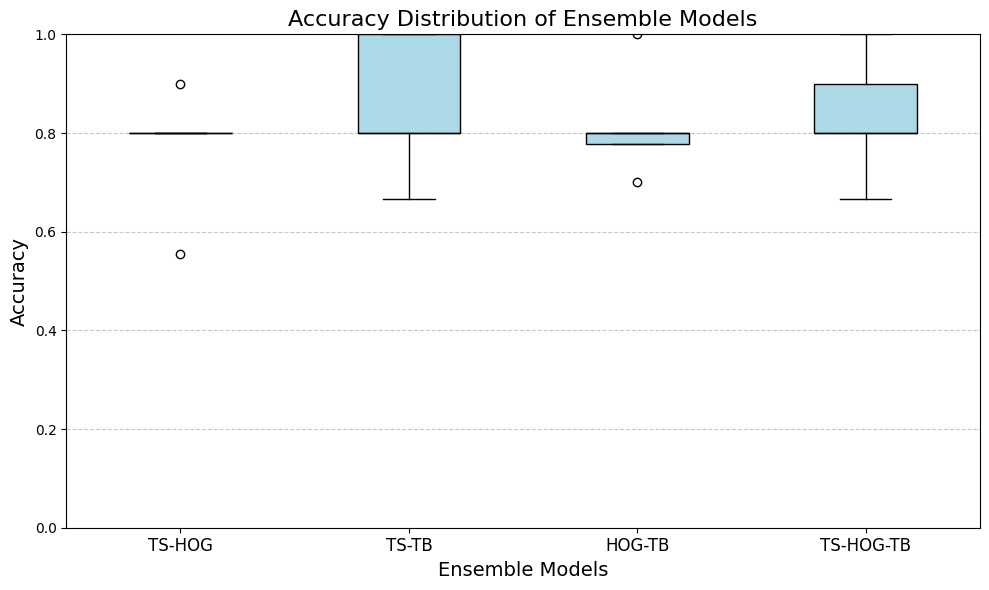

In [170]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot(
    [
        ensemble_accuracy_scores_TS_Pol,
        ensemble_accuracy_scores_TS_Tab,
        ensemble_accuracy_scores_Pol_Tab,
        ensemble_accuracy_scores_TS_Pol_Tab
    ],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='black')
)

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['TS-HOG', 'TS-TB', 'HOG-TB', 'TS-HOG-TB'], fontsize=12)

ax.set_ylabel('Accuracy', fontsize=14)
ax.set_xlabel('Ensemble Models', fontsize=14)
ax.set_title('Accuracy Distribution of Ensemble Models', fontsize=16)

ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('ensemble_accuracy_boxplots.pdf', dpi=300)
plt.show()

In [171]:
print("HOG + TB accuracy values:", ensemble_accuracy_scores_Pol_Tab)
print("Std dev:", np.std(ensemble_accuracy_scores_Pol_Tab))
print("Unique values:", np.unique(ensemble_accuracy_scores_Pol_Tab))

HOG + TB accuracy values: [1.0, 0.8, 0.8, 0.7, 0.7777777777777778]
Std dev: 0.09928136846083857
Unique values: [0.7        0.77777778 0.8        1.        ]


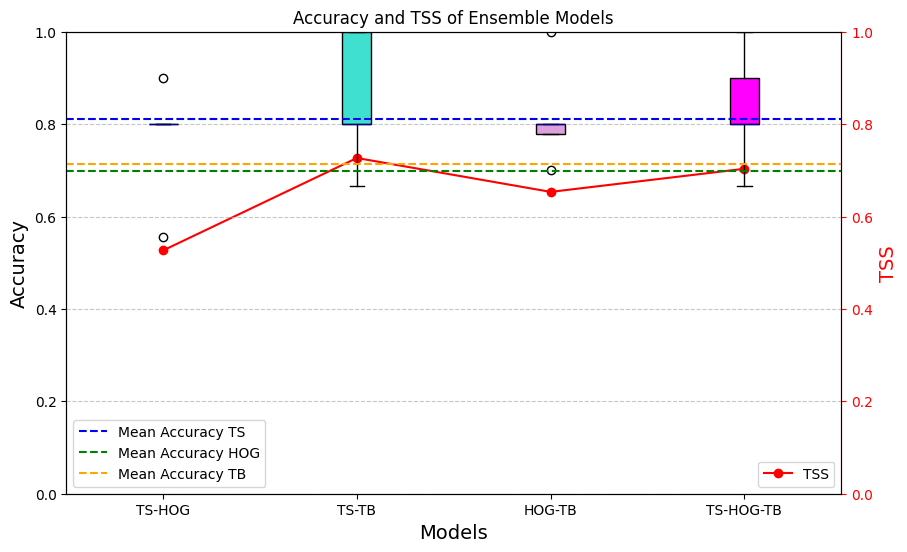

In [172]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate mean values for accuracy
mean_TSF_TS = np.mean(lst_accu_stratified_TSF)
mean_RF_Polygons = np.mean(accuracy_scores_RF_HOG)
mean_SVM_Tabular = np.mean(accuracy_values_SVM)

# Calculate mean values for TSS
mean_tss_ensemble1 = np.mean(tss_scores1)
mean_tss_ensemble2 = np.mean(mean_tss_ensemble2)
mean_tss_ensemble3 = np.mean(mean_tss_ensemble3)
mean_tss_ensemble4 = np.mean(mean_tss_ensemble4)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Box plot for Ensemble 1
ax1.boxplot(ensemble_accuracy_scores_TS_Pol, positions=[1], patch_artist=True,
            boxprops=dict(facecolor='deepskyblue'), medianprops=dict(color='darkblue'))

# Box plot for Ensemble 2
ax1.boxplot(ensemble_accuracy_scores_TS_Tab, positions=[2], patch_artist=True,
            boxprops=dict(facecolor='turquoise'), medianprops=dict(color='darkblue'))

# Box plot for Ensemble 3
ax1.boxplot(ensemble_accuracy_scores_Pol_Tab, positions=[3], patch_artist=True,
            boxprops=dict(facecolor='plum'), medianprops=dict(color='darkblue'))

# Box plot for Ensemble 4
ax1.boxplot(ensemble_accuracy_scores_TS_Pol_Tab, positions=[4], patch_artist=True,
            boxprops=dict(facecolor='magenta'), medianprops=dict(color='darkblue'))

# Add mean accuracy values as horizontal lines with labels
ax1.axhline(mean_TSF_TS, color='blue', linestyle='--', label='Mean Accuracy TS')
ax1.axhline(mean_RF_Polygons, color='green', linestyle='--', label='Mean Accuracy HOG')
ax1.axhline(mean_SVM_Tabular, color='orange', linestyle='--', label='Mean Accuracy TB')

# Labels and titles for the first y-axis (accuracy)
ax1.set_title('Accuracy and TSS of Ensemble Models')
ax1.set_xticks([1, 2, 3, 4])
ax1.set_xticklabels(['TS-HOG', 'TS-TB', 'HOG-TB', 'TS-HOG-TB'])
ax1.set_xlabel('Models', fontsize=14)
ax1.set_ylabel('Accuracy', fontsize=14)
ax1.set_ylim(0, 1)  # Accuracy axis from 0 to 1
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Create the second y-axis for TSS
ax2 = ax1.twinx()
ax2.set_ylabel('TSS', fontsize=14)
ax2.set_ylim(0, 1)  # Adjust the TSS range to be under the boxplots

# Set TSS y-axis to red
ax2.spines['right'].set_color('red')  # Right spine in red
ax2.tick_params(axis='y', colors='red')  # Tick labels in red
ax2.yaxis.label.set_color('red')  # Y-axis label in red

# Plot TSS scores as line plots with markers beneath the boxplots
ax2.plot([1, 2, 3, 4], [mean_tss_ensemble1, mean_tss_ensemble2, mean_tss_ensemble3, mean_tss_ensemble4],
         color='red', marker='o', linestyle='-', label='TSS')

# Adjust plot layout and ensure the TSS line plot is beneath the boxplots
ax1.set_zorder(2)  # Keep the boxplots on top
ax2.set_zorder(1)  # Send the TSS plot behind but make it visible
ax1.patch.set_visible(False)  # Ensure the boxplot's background doesn't cover TSS

# Add legends for accuracy and TSS
ax1.legend(loc='lower left')
ax2.legend(loc='lower right')

# Save as PDF
plt.savefig('accuracy_TSS_Ensemble_with_means_Updated.pdf', dpi=300)

plt.show()


In [173]:
best_predictions = (sep_probs >= best_threshold).astype(int)


In [174]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, best_predictions).ravel()

print("Confusion Matrix (Contingency Table)")
print("-------------------------------------")
print(f"TP (Hits):            {tp}")
print(f"FN (Misses):          {fn}")
print(f"FP (False Alarms):    {fp}")
print(f"TN (Correct Reject):  {tn}")


Confusion Matrix (Contingency Table)
-------------------------------------
TP (Hits):            3
FN (Misses):          2
FP (False Alarms):    1
TN (Correct Reject):  3


In [175]:
import pandas as pd

contingency_table = pd.DataFrame(
    [[tp, fn],
     [fp, tn]],
    index=["Observed Positive", "Observed Negative"],
    columns=["Predicted Positive", "Predicted Negative"]
)

print("\nContingency Table:")
print(contingency_table)



Contingency Table:
                   Predicted Positive  Predicted Negative
Observed Positive                   3                   2
Observed Negative                   1                   3


In [176]:
tpr = tp / (tp + fn)
fpr = fp / (fp + tn)
acc = (tp + tn) / (tp + tn + fp + fn)
tss = tpr - fpr

print("\nDerived Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"TPR (Recall): {tpr:.4f}")
print(f"FPR: {fpr:.4f}")
print(f"TSS: {tss:.4f}")



Derived Metrics:
Accuracy: 0.6667
TPR (Recall): 0.6000
FPR: 0.2500
TSS: 0.3500
